<div style="text-align: center; padding: 30px; background-color: #f5f7fa; border-radius: 12px; box-shadow: 0px 4px 10px rgba(0,0,0,0.1);">

  <h1 style="color: #2c3e50; font-family: 'Helvetica Neue', sans-serif; font-size: 42px; margin-bottom: 10px;">
    Virtual Lab 9 Project
  </h1>

  <h3 style="color: #7f8c8d; font-family: 'Georgia', serif; font-weight: normal; font-size: 22px; margin-top: 0;">
    Integrative Bioinformatics for Studying PTM Networks
  </h3>

  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 16px; margin-top: 20px;">
    Author: <b>Vallari Eastman</b> <br>
    Due Date: <b>Monday November 10th, 2025 11:59 p.m. ET</b>
  </p>
</div>

<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Introduction:
  </h2>
<p style="text-indent:30px; color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px; line-height:1.6;">
    This project compares three phosphorylation prediction platforms (PHOSforUS, NetPhos, and MusiteDeep) to evaluate how different computational approaches identify serine, threonine, and tyrosine phosphorylation sites across the same protein dataset. Each tool uses distinct modeling strategies, probability scales, and feature sets, so a unified parsing and analysis workflow was developed to standardize outputs, compute residue-specific statistics, and visualize prediction patterns.
</p>

<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Methods:
  </h2>
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:0;">
    <b> Phosphorylation Site Prediction Work Flow</b>
  </h3> 
   <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
       <b>PHOSforUS</b><br>
       1. Fork and Clone PHOSforUS repository<br>
       2. Run for each FASTA<br>
       3. Save results and analyze<br><br>
       <b>Netphos</b><br>
       1. Submit FASTA sequences to NetPhos 3.1<br>
       2. Download the plain-text results<br>
       3. Clean up headers if needed (# sp_O00418_EF2K_HUMAN ... format)<br>
       4. Analyze<br><br>
       <b>MusiteDeep</b><br>
       1. Fork and Clone PHOSforUS repository<br>
       2. Run for each FASTA<br>
       3. Save results and analyze<br><br>
   </p>
</div>

# PHOSforUS Tutorial Section:

<b>PHOSforUS:</b> <br>
PHOSforUS is a fully biophysical parameter-based protein phosphorylation site predictor. <br>

From input sequences, it calculates 18 biophysical features, including:<br>
<b>Horizontal features (6):</b> Hydrophobicity, Secondary structure propensity, PII propensity, etc.<br>
<b>Vertical features (4):</b>  AA molecular weight, residue charge, surface area, etc.<br>
<b>eSCAPE thermodynamic features (8): </b> dG, dHap, dHpol, TdS, etc.<br><br>
All individual biophysical features are sent to sub-predictors, based on Naive Bayes classifier. Resulting scores are sent to downstream metapredictor, based on gradient boosting classifier. Prediction results are compiled into single result file per each sequence, which could be found in result_output folder.<br><br>
requires: <br>
Python 2.7 <br>
numpy: 1.16.5 <br>
scikit-learn: 0.20.3 <br>
Note to self: new environment created for this (py27Legacy)

In [90]:
# Test Phosforus package
from phosforus import phosforus
phosforus.phosforus("ACDEFGHIKLMNPQRSTVWY", file_input = False, manual_input = True, verbose = True)

#### Manual sequence input completed

16 	S- 	NONPHOS 	-2.069651886534991 	0.11208167791355839
17 	T- 	NONPHOS 	-1.9764498918166105 	0.12169779052456121
20 	Y- 	NONPHOS 	-1.6653887258075397 	0.15903995020631137
## Entry 1 calculation completed: >Manual_seq_input


In [91]:
# runs phosforus on test data
phosforus.phosforus("testing_proteins_CDK.fasta")

#### Sequence input completed
## Entry 1 calculation completed: >sp|P10275|ANDR_HUMAN And
## Entry 2 calculation completed: >sp|O15392|BIRC5_HUMAN Ba
## Entry 3 calculation completed: >sp|Q8WXE1|ATRIP_HUMAN AT
## Entry 4 calculation completed: >sp|P51587|BRCA2_HUMAN Br
## Entry 5 calculation completed: >sp|P51946|CCNH_HUMAN Cyc
## Entry 6 calculation completed: >sp|P50613|CDK7_HUMAN Cyc
## Entry 7 calculation completed: >sp|P67870|CSK2B_HUMAN Ca
## Entry 8 calculation completed: >sp|Q9Y6I3|EPN1_HUMAN Eps
## Entry 9 calculation completed: >sp|Q08050|FOXM1_HUMAN Fo
## Entry 10 calculation completed: >sp|P02545|LMNA_HUMAN Pre
## Entry 11 calculation completed: >sp|P52926|HMGA2_HUMAN Hi
## Entry 12 calculation completed: >sp|P54198|HIRA_HUMAN Pro
## Entry 13 calculation completed: >sp|P41236|IPP2_HUMAN Pro
## Entry 14 calculation completed: >sp|P05787|K2C8_HUMAN Ker
## Entry 15 calculation completed: >sp|P48200|IREB2_HUMAN Ir
## Entry 16 calculation completed: >sp|Q14847|LASP1_HUMAN LI
## 

In [92]:
# --- Scrollable Window for Results (Python 2.7 version) ---
from IPython.display import HTML, display
import os, cgi

REL_PATH = "CDKresults.txt"

# Find the file (absolute or relative path)
if os.path.exists(REL_PATH):
    path = REL_PATH
elif os.path.exists(os.path.abspath(REL_PATH)):
    path = os.path.abspath(REL_PATH)
else:
    display(HTML(
        "<b style='color:red;'>File not found:</b> %s<br><b>cwd:</b> %s"
        % (cgi.escape(REL_PATH), cgi.escape(os.getcwd()))
    ))
    raise SystemExit

# Read and escape text
with open(path, "r") as fh:
    text = fh.read()

escaped = cgi.escape(text)

# Display as scrollable HTML
html_block = """
<div style="border:1px solid #ccc;border-radius:6px;
            overflow:auto;max-height:420px;background:#fbfbfb;">
  <div style="padding:6px 10px;font:13px monospace;background:#f7f7f7;">
    %s
  </div>
  <pre style="margin:0;padding:10px;font:13px monospace;
              white-space:pre-wrap;word-break:break-word;">%s</pre>
</div>
""" % (cgi.escape(REL_PATH), escaped)

display(HTML(html_block))

In [93]:
phosforus.phosforus("testing_proteins_MAPK.fasta")

#### Sequence input completed
## Entry 1 calculation completed: >sp|P17544|ATF7_HUMAN Cyc
## Entry 2 calculation completed: >sp|Q07817|B2CL1_HUMAN Bc
## Entry 3 calculation completed: >sp|P17655|CAN2_HUMAN Cal
## Entry 4 calculation completed: >sp|P46527|CDN1B_HUMAN Cy
## Entry 5 calculation completed: >sp|P41182|BCL6_HUMAN B-c
## Entry 6 calculation completed: >sp|Q53EZ4|CEP55_HUMAN Ce
## Entry 7 calculation completed: >sp|P49715|CEBPA_HUMAN CC
## Entry 8 calculation completed: >sp|P14635|CCNB1_HUMAN G2
## Entry 9 calculation completed: >sp|P53355|DAPK1_HUMAN De
## Entry 10 calculation completed: >sp|O00418|EF2K_HUMAN Euk
## Entry 11 calculation completed: >sp|P14921|ETS1_HUMAN Pro
## Entry 12 calculation completed: >sp|P98177|FOXO4_HUMAN Fo
## Entry 13 calculation completed: >sp|P50548|ERF_HUMAN ETS 
## Entry 14 calculation completed: >sp|P04150|GCR_HUMAN Gluc
## Entry 15 calculation completed: >sp|Q13322|GRB10_HUMAN Gr
## Entry 16 calculation completed: >sp|P49137|MAPK2_HUMAN MA
## 

In [94]:
# --- Scrollable Window for Results (Python 2.7 version) ---
from IPython.display import HTML, display
import os, cgi

REL_PATH = "MAPKresults.txt"

# Find the file (absolute or relative path)
if os.path.exists(REL_PATH):
    path = REL_PATH
elif os.path.exists(os.path.abspath(REL_PATH)):
    path = os.path.abspath(REL_PATH)
else:
    display(HTML(
        "<b style='color:red;'>File not found:</b> %s<br><b>cwd:</b> %s"
        % (cgi.escape(REL_PATH), cgi.escape(os.getcwd()))
    ))
    raise SystemExit

# Read and escape text
with open(path, "r") as fh:
    text = fh.read()

escaped = cgi.escape(text)

# Display as scrollable HTML
html_block = """
<div style="border:1px solid #ccc;border-radius:6px;
            overflow:auto;max-height:420px;background:#fbfbfb;">
  <div style="padding:6px 10px;font:13px monospace;background:#f7f7f7;">
    %s
  </div>
  <pre style="margin:0;padding:10px;font:13px monospace;
              white-space:pre-wrap;word-break:break-word;">%s</pre>
</div>
""" % (cgi.escape(REL_PATH), escaped)

display(HTML(html_block))

Loaded: CDKresults.txt
Number of records:  3832
Data columns: ['position', 'residue_info', 'prediction', 'score', 'probability']
Loaded: MAPKresults.txt
Number of records:  3619
Data columns: ['position', 'residue_info', 'prediction', 'score', 'probability']

CDK Statistics:
+--------------------------+--------------+
| Metric                   |        Value |
+==========================+==============+
| Max Probability          |    0.946877  |
+--------------------------+--------------+
| Mean Probability         |    0.510617  |
+--------------------------+--------------+
| Mean Score               |    0.0334019 |
+--------------------------+--------------+
| Min Probability          |    0.0438388 |
+--------------------------+--------------+
| Non-phosphorylated Sites | 1779         |
+--------------------------+--------------+
| Phosphorylated Sites     | 2053         |
+--------------------------+--------------+
| Phosphorylation Rate     |    0.535752  |
+-------------------

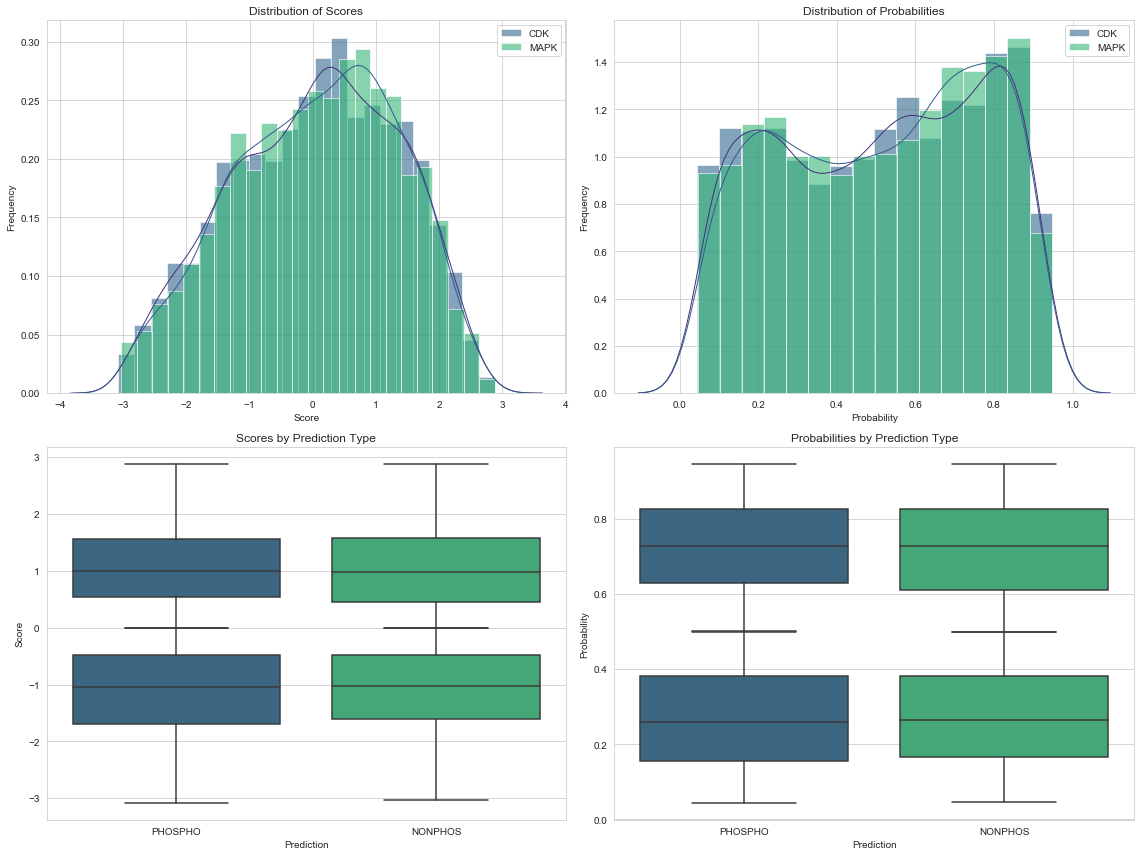

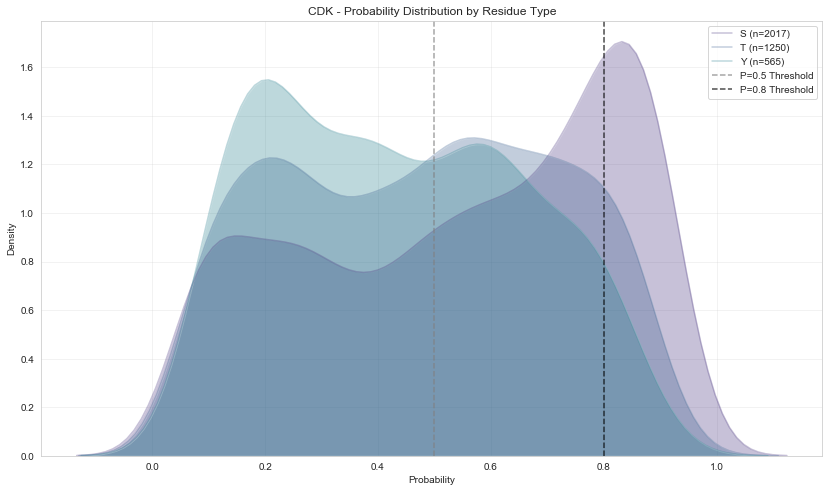

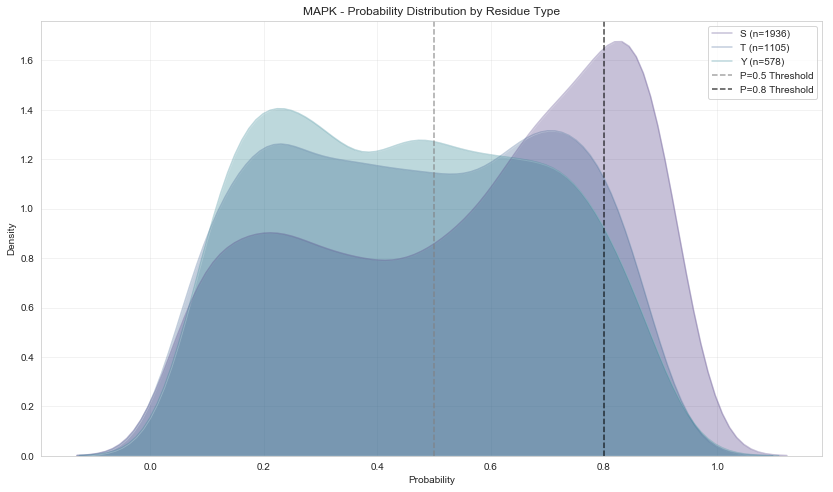


Context patterns for CDK:
-    3574
P     258

Phosphorylation rate by context for CDK:
         Phosphorylated  Total  Phosphorylation Rate
context                                             
P                   148    258              0.573643
-                  1905   3574              0.533016


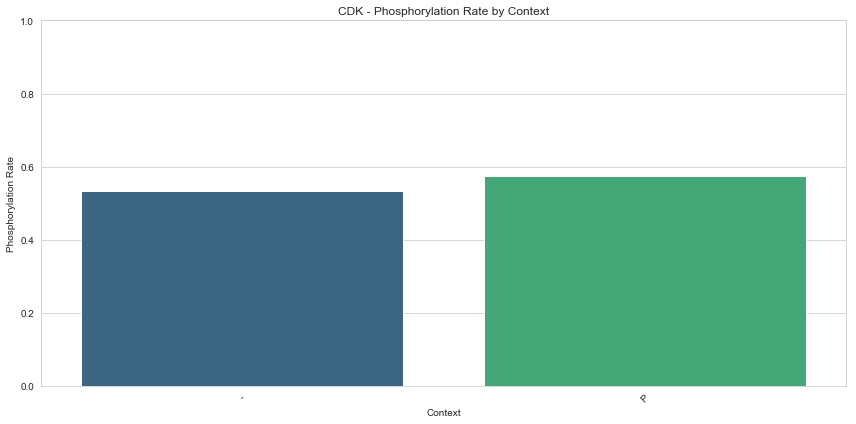

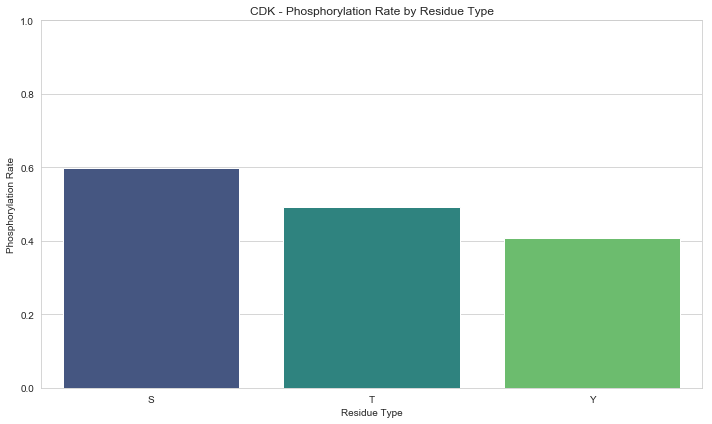


Context patterns for MAPK:
-    3303
P     316

Phosphorylation rate by context for MAPK:
         Phosphorylated  Total  Phosphorylation Rate
context                                             
P                   208    316              0.658228
-                  1740   3303              0.526794


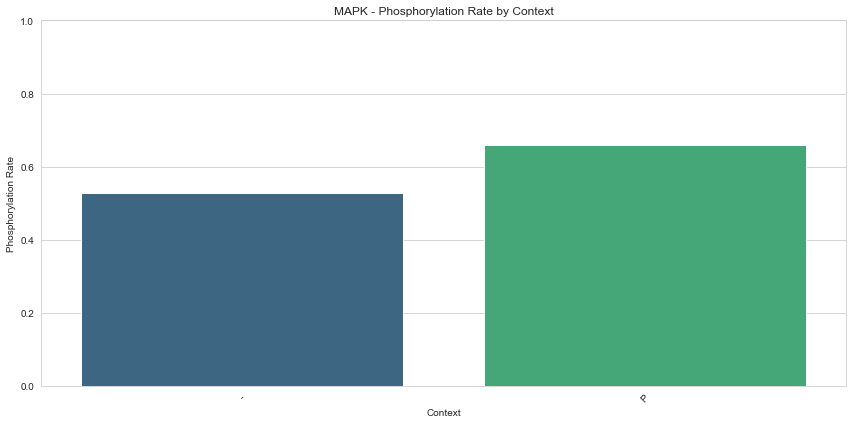

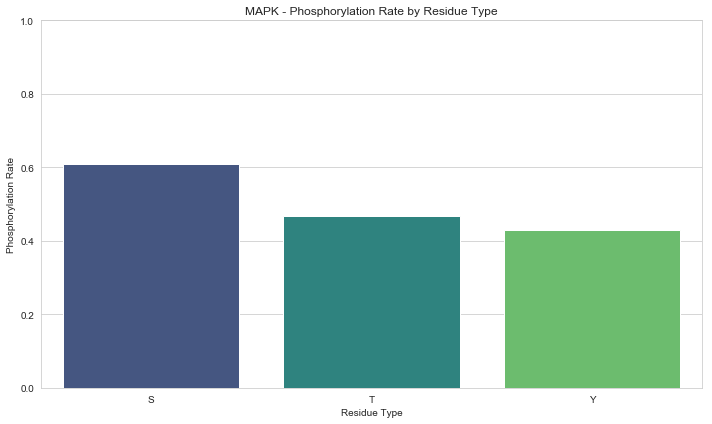

Created network for CDK with 515 nodes and 514 edges


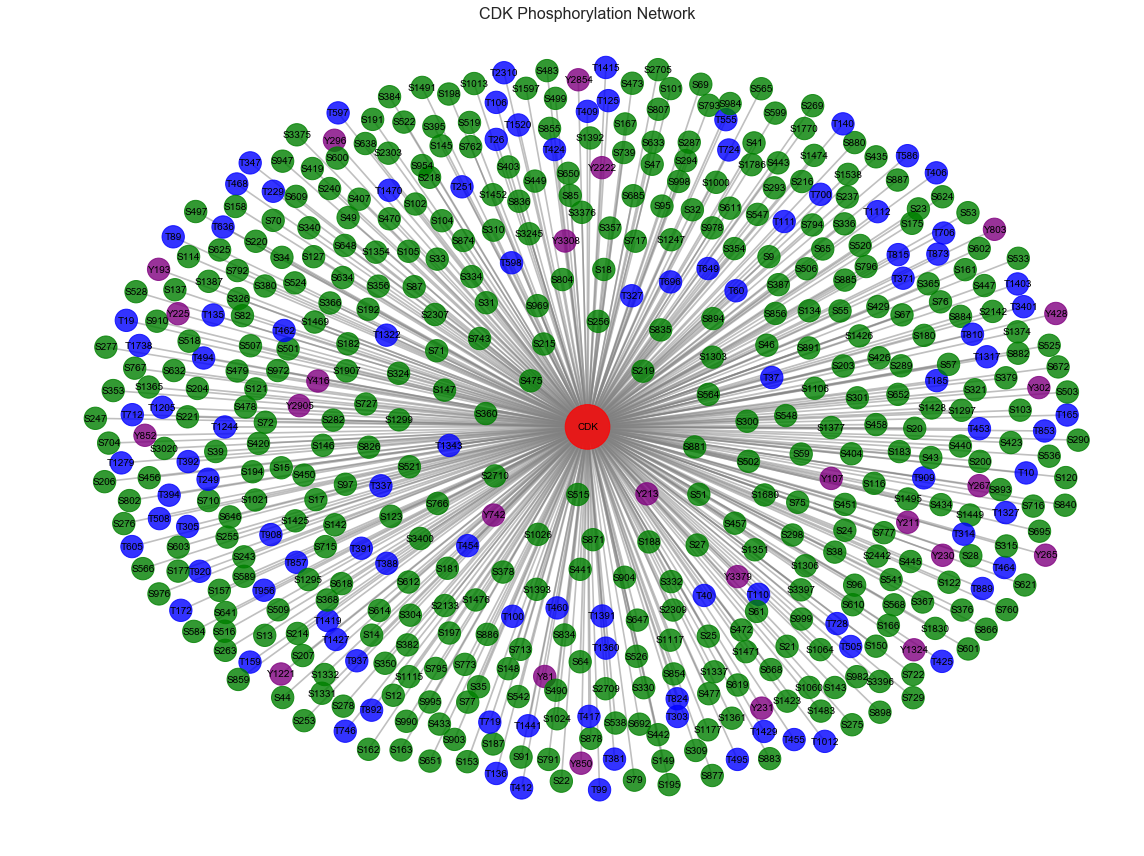

Network Metrics for CDK Phosphorylation Network:
  Average Clustering: 0.0
  Nodes: 515
  Edges: 514
  Connected Components: 1
  Density: 0.00388349514563
High confidence sites by residue type:
  Y: 25
  S: 387
  T: 102
Created network for MAPK with 418 nodes and 417 edges


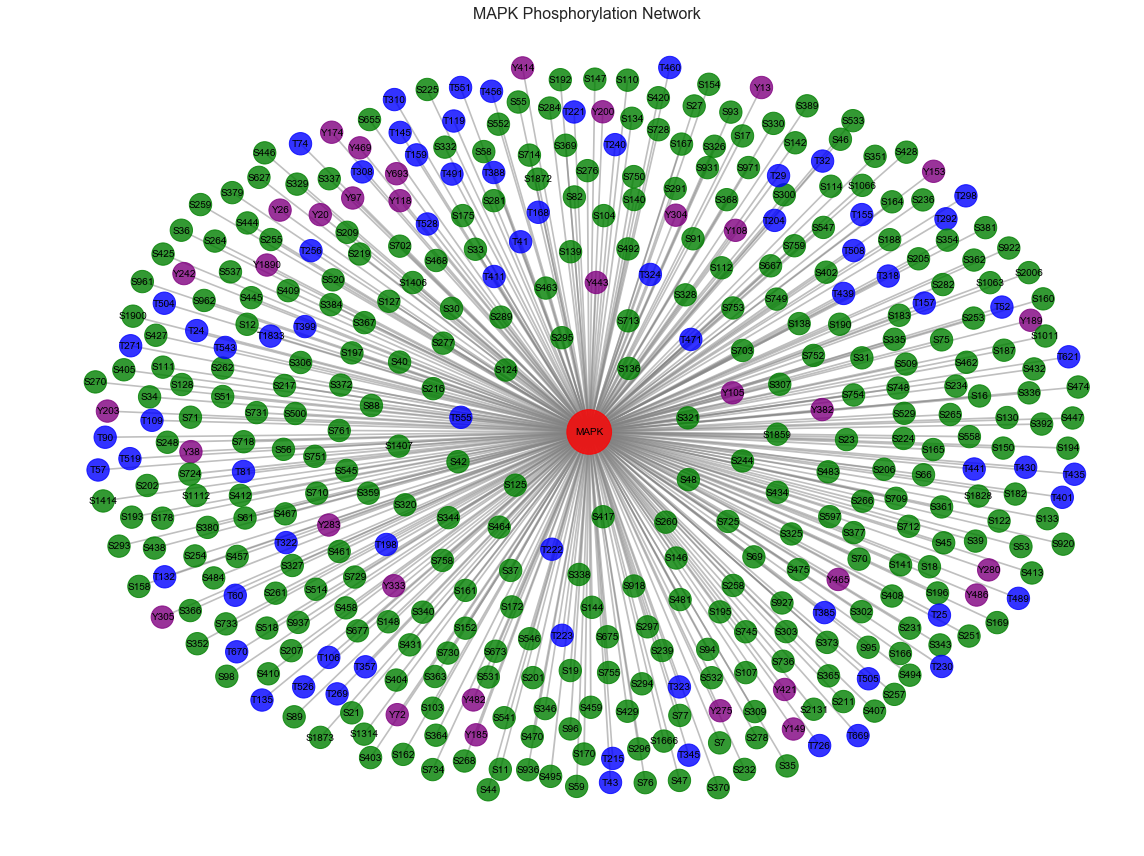

Network Metrics for MAPK Phosphorylation Network:
  Average Clustering: 0.0
  Nodes: 418
  Edges: 417
  Connected Components: 1
  Density: 0.00478468899522
High confidence sites by residue type:
  Y: 33
  S: 313
  T: 71

Network Comparison:
     Nodes Edges     Density Average Clustering
CDK    515   514   0.0038835                  0
MAPK   418   417  0.00478469                  0


<Figure size 864x432 with 0 Axes>

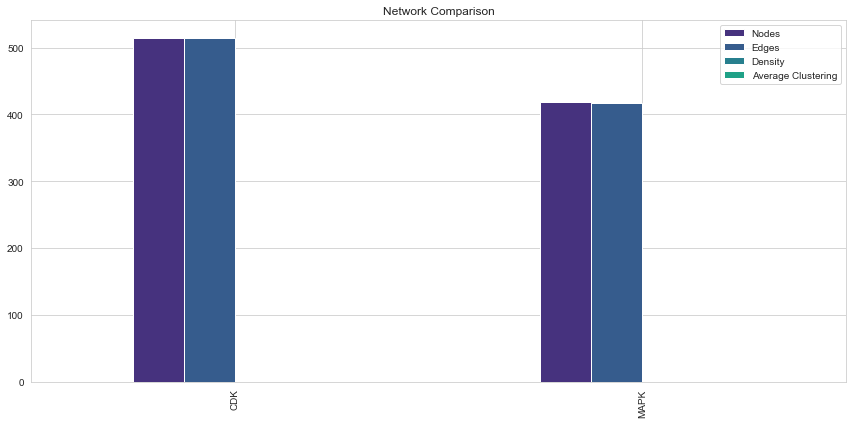

<Figure size 720x432 with 0 Axes>

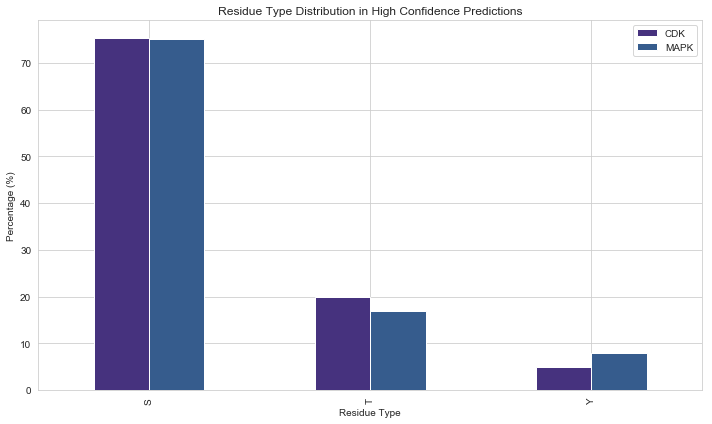


=== Horizontal Features Comparison (Context Patterns) ===
Contexts with biggest difference in phosphorylation rate between CDK and MAPK:
   CDK_count  CDK_phospho_rate Context  Difference  MAPK_count  \
1       3574          0.533016       -    0.006222        3303   
0        258          0.573643       P   -0.084584         316   

   MAPK_phospho_rate  
1           0.526794  
0           0.658228  


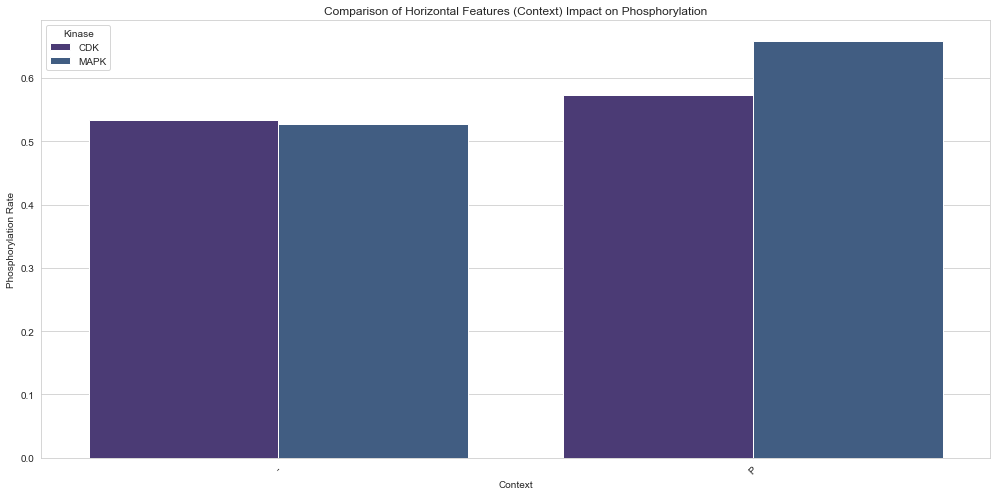


=== Vertical Features Comparison (Residue Types) ===
Residue types with differences in phosphorylation rate between CDK and MAPK:
   CDK_count  CDK_phospho_rate  Difference  MAPK_count  MAPK_phospho_rate  \
1       1250          0.491200    0.022422        1105           0.468778   
0       2017          0.598909   -0.011628        1936           0.610537   
2        565          0.408850   -0.020216         578           0.429066   

  Residue  
1       T  
0       S  
2       Y  


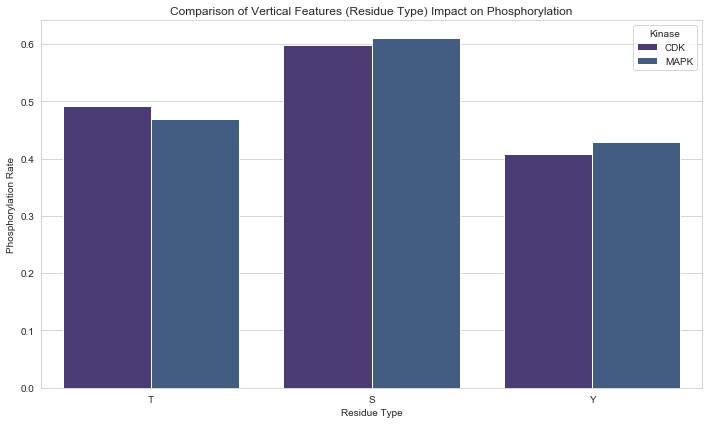


=== Summary of Feature Importance ===
 H/V Ratio  Horizontal Variation Kinase  Vertical Variation
  0.261028              0.020314    CDK            0.077821
  0.843693              0.065717   MAPK            0.077892


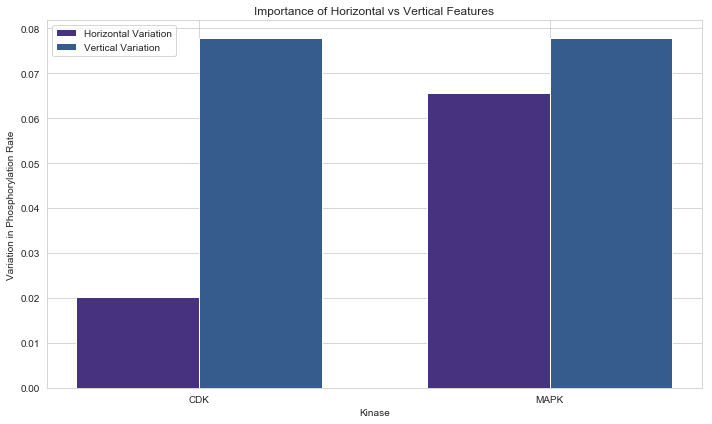

In [115]:
# PHOSforUS Analysis - Protein Phosphorylation Prediction
# This script analyzes data from PHOSforUS output files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter
import os
import re

# Load and Prepare Data
def load_phosfor_results(file_path):
    """Load PHOSforUS result file with the correct format"""
    # Check if file exists
    if not os.path.exists(file_path):
        print("File not found: {}".format(file_path))
        return None
    
    # Load the file as text first to check the format and skip header lines
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Skip header lines 
    data_lines = []
    for line in lines:
        if line.startswith('####') or line.strip() == '':
            continue
        elif line.startswith('##'):
            continue  # Skip entry completion lines
        else:
            data_lines.append(line.strip())
    
    # Create a pandas DataFrame with the correct columns
    data = []
    for line in data_lines:
        if line.startswith("Sites") or line.strip() == "":
                continue  # skip header or blank lines
        parts = line.split()
        if len(parts) >= 5:  # Ensure there are at least 5 columns
            position = int(parts[0])
            residue_info = parts[1]
            prediction = parts[2]
            score = float(parts[3])
            probability = float(parts[4])
            data.append([position, residue_info, prediction, score, probability])
        # except ValueError:
                    # continue  # skip malformed lines
    
    # Create DataFrame with appropriate column names
    df = pd.DataFrame(data, columns=['position', 'residue_info', 'prediction', 'score', 'probability'])
    
    # Display basic information
    print("Loaded: {}".format(file_path))
    print("Number of records:  {}".format(len(df)))
    print("Data columns: {}".format(df.columns.tolist()))
    
    # Doesn't work in python 2.7
    # print(f"Loaded {file_path}")
    # print(f"Number of records: {len(df)}")
    # print(f"Data columns: {df.columns.tolist()}")
    
    return df

# Load the CDK and MAPK results
cdk_results = load_phosfor_results('CDKresults.txt')
mapk_results = load_phosfor_results('MAPKresults.txt')

# Basic Data Analysis
from tabulate import tabulate

def analyze_result_stats(results, kinase_name):
    """Calculate basic statistics for the results"""
    if results is None:
        return None
    
    # Calculate overall statistics
    stats = {
        'Total Sites': len(results),
        'Phosphorylated Sites': sum(results['prediction'] == 'PHOSPHO'),
        'Non-phosphorylated Sites': sum(results['prediction'] == 'NONPHOS'),
        'Phosphorylation Rate': float(sum(results['prediction'] == 'PHOSPHO')) / len(results),
        'Mean Score': results['score'].mean(),
        'Mean Probability': results['probability'].mean(),
        'Min Probability': results['probability'].min(),
        'Max Probability': results['probability'].max()
    }

    # Extract residue types from residue_info column
    results['residue_type'] = results['residue_info'].str[0]

    # Count sites by residue type
    residue_counts = results['residue_type'].value_counts()
    for residue, count in residue_counts.items():
        stats['{} Sites'.format(residue)] = count

    # Count phosphorylated sites by residue type
    phospho_by_residue = results[results['prediction'] == 'PHOSPHO']['residue_type'].value_counts()
    for residue, count in phospho_by_residue.items():
        stats['{} Phosphorylated'.format(residue)] = count
        total_residue = residue_counts.get(residue, 0)
        if total_residue > 0:
            stats['{} Phosphorylation Rate'.format(residue)] = float(count) / total_residue

    # Create a dataframe for the statistics
    stats_df = pd.DataFrame([stats], index=[kinase_name])
    
    return stats_df

# Analyze statistics for both datasets
cdk_stats = analyze_result_stats(cdk_results, 'CDK')
mapk_stats = analyze_result_stats(mapk_results, 'MAPK')

# Display statistics
print("\nCDK Statistics:")
print(tabulate(cdk_stats.T, headers=["Metric", "Value"], tablefmt="grid"))

print("\nMAPK Statistics:")
print(tabulate(mapk_stats.T, headers=["Metric", "Value"], tablefmt="grid"))

# Compare statistics side by side
# --- Side-by-side stats table (uses tabulate) ---
if cdk_stats is not None and mapk_stats is not None:
    combined_stats = pd.concat([cdk_stats, mapk_stats])
    print("\nComparison of CDK and MAPK Statistics:\n")

    # Transpose so metrics are rows, kinases are columns
    table = tabulate(combined_stats.T,
                     headers=["Metric", "CDK", "MAPK"],
                     tablefmt="grid",  # or "fancy_grid", "github", etc.
                     showindex=True)
    print(table)

# Set plot style
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.rcParams['figure.figsize'] = (12, 8)
# sns.set_palette("viridis")

def plot_score_distributions(results_list, labels):
    """Plot score and probability distributions (Python 2.7 compatible)"""
    if not all(r is not None for r in results_list):
        print("Cannot plot distributions - missing data")
        return

    # Ensure residue_type exists
    for r in results_list:
        if 'residue_type' not in r.columns:
            r['residue_type'] = r['residue_info'].str[0]

    # Colors for series (avoid f-strings / 'C{i}')
    colors = sns.color_palette("viridis", n_colors=len(results_list))

    # 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Distributions
    for i, (results, label) in enumerate(zip(results_list, labels)):
        # Score distribution (use distplot instead of histplot)
        sns.distplot(results['score'].dropna(),
                     kde=True,
                     ax=axes[0, 0],
                     hist_kws={'alpha': 0.6, 'color': colors[i]},
                     kde_kws={'linewidth': 1})
        axes[0, 0].legend(labels)

        # Probability distribution
        sns.distplot(results['probability'].dropna(),
                     kde=True,
                     ax=axes[0, 1],
                     hist_kws={'alpha': 0.6, 'color': colors[i]},
                     kde_kws={'linewidth': 1})
        axes[0, 1].legend(labels)

        # Scores by prediction (boxplot)
        sns.boxplot(x='prediction', y='score',
                    data=results,
                    ax=axes[1, 0],
                    palette=sns.color_palette("viridis", 2))

        # Probabilities by prediction (boxplot)
        sns.boxplot(x='prediction', y='probability',
                    data=results,
                    ax=axes[1, 1],
                    palette=sns.color_palette("viridis", 2))

    # Titles/labels
    axes[0, 0].set_title('Distribution of Scores')
    axes[0, 0].set_xlabel('Score')
    axes[0, 0].set_ylabel('Frequency')

    axes[0, 1].set_title('Distribution of Probabilities')
    axes[0, 1].set_xlabel('Probability')
    axes[0, 1].set_ylabel('Frequency')

    axes[1, 0].set_title('Scores by Prediction Type')
    axes[1, 0].set_xlabel('Prediction')
    axes[1, 0].set_ylabel('Score')

    axes[1, 1].set_title('Probabilities by Prediction Type')
    axes[1, 1].set_xlabel('Prediction')
    axes[1, 1].set_ylabel('Probability')

    plt.tight_layout()
    plt.show()

    # Probability KDE by residue type (per dataset)
    for results, label in zip(results_list, labels):
        plt.figure(figsize=(14, 8))
        residue_types = sorted(results['residue_type'].dropna().unique())

        for residue in residue_types:
            subset = results[results['residue_type'] == residue]
            if len(subset) > 5:
                # seaborn<=0.9: use shade=True (not 'fill=')
                sns.kdeplot(subset['probability'].dropna(),
                            label='{} (n={})'.format(residue, len(subset)),
                            shade=True,
                            alpha=0.3)

        plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='P=0.5 Threshold')
        plt.axvline(x=0.8, color='black', linestyle='--', alpha=0.7, label='P=0.8 Threshold')

        plt.title('{} - Probability Distribution by Residue Type'.format(label))
        plt.xlabel('Probability')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# Call it
plot_score_distributions([cdk_results, mapk_results], ['CDK', 'MAPK'])

# Analyze Residue Context and Motifs
def extract_sequence_context(results, kinase_name):
    """Extract sequence context information from residue_info column (Py2.7 ready)."""
    if results is None:
        return

    # Ensure required columns exist
    if 'residue_info' not in results.columns:
        print("Missing 'residue_info' column.")
        return
    if 'prediction' not in results.columns:
        print("Missing 'prediction' column.")
        return

    # Add residue_type and context columns
    # Assumes strings like "SP", "TP", "S-", etc.
    results = results.copy()
    results['residue_type'] = results['residue_info'].astype(str).str[0]
    results['context'] = results['residue_info'].astype(str).str[1:]

    # Analyze context patterns
    context_patterns = results['context'].value_counts()

    print("\nContext patterns for {}:".format(kinase_name))
    # Print top 10 as a neat table
    print(context_patterns.head(10).to_string())

    # Count phosphorylation by context
    phospho_by_context = results[results['prediction'] == 'PHOSPHO'].groupby('context').size()
    total_by_context = results.groupby('context').size()

    # Combine and compute rates
    context_stats = pd.DataFrame({
        'Total': total_by_context,
        'Phosphorylated': phospho_by_context
    }).fillna(0)

    # Ensure float division
    context_stats['Phosphorylation Rate'] = context_stats['Phosphorylated'].astype(float) / context_stats['Total'].replace(0, pd.np.nan)
    context_stats = context_stats.sort_values('Phosphorylation Rate', ascending=False)

    print("\nPhosphorylation rate by context for {}:".format(kinase_name))
    print(context_stats.head(10).to_string())

    # ----- Plot: top contexts by phosphorylation rate -----
    plt.figure(figsize=(12, 6))
    top_contexts = list(context_patterns.head(10).index)

    # Align the rates to the same order; missing contexts -> NaN (drop them)
    context_rates = context_stats.reindex(top_contexts)['Phosphorylation Rate'].dropna()

    # Build a small plotting frame (safer for older seaborn)
    df_ctx = pd.DataFrame({
        'context': context_rates.index,
        'rate': context_rates.values
    })

    sns.barplot(x='context', y='rate', data=df_ctx, palette='viridis')
    plt.title('{} - Phosphorylation Rate by Context'.format(kinase_name))
    plt.xlabel('Context')
    plt.ylabel('Phosphorylation Rate')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    # ----- Residue type correlation with phosphorylation -----
    phospho_by_residue = results[results['prediction'] == 'PHOSPHO']['residue_type'].value_counts()
    total_by_residue = results['residue_type'].value_counts()

    residue_stats = pd.DataFrame({
        'Total': total_by_residue,
        'Phosphorylated': phospho_by_residue
    }).fillna(0)

    residue_stats['Phosphorylation Rate'] = residue_stats['Phosphorylated'].astype(float) / residue_stats['Total'].replace(0, pd.np.nan)

    # Plot residue-type rates
    plt.figure(figsize=(10, 6))
    # Reset index so seaborn can read columns directly
    df_res = residue_stats.reset_index()
    df_res.columns = ['residue_type', 'Total', 'Phosphorylated', 'Phosphorylation Rate']

    sns.barplot(x='residue_type', y='Phosphorylation Rate', data=df_res, palette='viridis')
    plt.title('{} - Phosphorylation Rate by Residue Type'.format(kinase_name))
    plt.xlabel('Residue Type')
    plt.ylabel('Phosphorylation Rate')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    return residue_stats

# Analyze residue context for both datasets
cdk_residue_stats = extract_sequence_context(cdk_results, 'CDK')
mapk_residue_stats = extract_sequence_context(mapk_results, 'MAPK')

# Network Analysis
def create_protein_network(results, kinase_name, confidence_threshold=0.8):
    """Create a network from phosphorylation predictions"""
    if results is None:
        return None
    
    # Create an empty graph
    G = nx.Graph()
    
    # Add kinase as central node
    G.add_node(kinase_name, node_type='kinase', size=2000, color='red')

    # Ensure residue_type column exists
    if 'residue_type' not in results.columns and 'residue_info' in results.columns:
        results = results.copy()
        results['residue_type'] = results['residue_info'].astype(str).str[0]

    # High-confidence subset
    high_conf = results[results['probability'] >= confidence_threshold]

    # Add site nodes and edges
    for _, row in high_conf.iterrows():
        substrate_id = "Site_{}".format(row['position'])
        site_type = "{}{}".format(row['residue_type'], row['position'])

        G.add_node(substrate_id,
                   node_type='site',
                   size=500,
                   residue=row['residue_type'],
                   position=row['position'],
                   color=('green' if row['residue_type'] == 'S'
                          else 'blue' if row['residue_type'] == 'T'
                          else 'purple'))

        G.add_edge(kinase_name, substrate_id,
                   weight=row['probability'],
                   score=row.get('score', None))

    print("Created network for {} with {} nodes and {} edges".format(
        kinase_name, G.number_of_nodes(), G.number_of_edges()))
    return G

def visualize_network(G, title):
    """Visualize a protein phosphorylation network"""
    if G is None:
        return

    plt.figure(figsize=(16, 12))

    # NetworkX 1.x doesn't support seed= in spring_layout; set NumPy seed instead
    np.random.seed(42)
    pos = nx.spring_layout(G, k=0.3, iterations=50)

    # ---- Node attributes (NetworkX 1.x: use G.node[...] not G.nodes[...]) ----
    node_types = nx.get_node_attributes(G, 'node_type')
    node_sizes = [G.node[n].get('size', 300) for n in G.nodes()]
    node_colors = [G.node[n].get('color', 'blue') for n in G.nodes()]

    # Draw nodes and edges
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)

    edge_weights = [(G[u][v].get('weight', 1.0) * 2.0) for (u, v) in G.edges()]
    nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.5, edge_color='gray')

    # Labels
    labels = {}
    for n in G.nodes():
        if node_types.get(n) == 'kinase':
            labels[n] = n
        elif node_types.get(n) == 'site':
            residue = G.node[n].get('residue', '')
            position = G.node[n].get('position', '')
            labels[n] = "{}{}".format(residue, position)

    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)

    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # ---- Metrics (available in NetworkX 1.x) ----
    metrics = {
        'Nodes': G.number_of_nodes(),
        'Edges': G.number_of_edges(),
        'Density': nx.density(G),
        'Average Clustering': nx.average_clustering(G),
        'Connected Components': nx.number_connected_components(G),
    }

    print("Network Metrics for {}:".format(title))
    for metric, value in metrics.items():
        print("  {}: {}".format(metric, value))

    # Count high-confidence sites by residue type
    residue_counts = {}
    for n, data in G.nodes(data=True):
        if data.get('node_type') == 'site':
            residue = data.get('residue', '')
            residue_counts[residue] = residue_counts.get(residue, 0) + 1

    print("High confidence sites by residue type:")
    for residue, count in residue_counts.items():
        print("  {}: {}".format(residue, count))

        # Create and visualize networks
cdk_network = create_protein_network(cdk_results, 'CDK')
visualize_network(cdk_network, 'CDK Phosphorylation Network')

mapk_network = create_protein_network(mapk_results, 'MAPK')
visualize_network(mapk_network, 'MAPK Phosphorylation Network')

# Compare Networks
def compare_networks(networks, names):
    """Compare multiple phosphorylation networks"""
    if not all(networks):
        print("Cannot compare networks - one or more networks are missing")
        return
    
    # Collect metrics for comparison
    metrics = ['Nodes', 'Edges', 'Density', 'Average Clustering']
    comparison = pd.DataFrame(index=names, columns=metrics)
    
    for i, G in enumerate(networks):
        name = names[i]
        comparison.loc[name, 'Nodes'] = G.number_of_nodes()
        comparison.loc[name, 'Edges'] = G.number_of_edges()
        comparison.loc[name, 'Density'] = nx.density(G)
        comparison.loc[name, 'Average Clustering'] = nx.average_clustering(G)
    
    # Display comparison table
    print("\nNetwork Comparison:")
    print(comparison)
    
    # Visualize comparison
    plt.figure(figsize=(12, 6))
    comparison.plot(kind='bar', figsize=(12, 6))
    plt.title('Network Comparison')
    plt.tight_layout()
    plt.show()
    
    # Compare residue type distribution in high confidence predictions
    residue_distributions = {}
    
    for i, G in enumerate(networks):
        name = names[i]
        residue_counts = {}
        
        for n, data in G.nodes(data=True):
            if data.get('node_type') == 'site':
                residue = data.get('residue', '')
                if residue in residue_counts:
                    residue_counts[residue] += 1
                else:
                    residue_counts[residue] = 1
        
        residue_distributions[name] = residue_counts
    
    # Create a DataFrame for residue distribution
    residue_df = pd.DataFrame(residue_distributions)
    residue_df = residue_df.fillna(0)
    
    # Convert to percentage
    for col in residue_df.columns:
        residue_df[col] = residue_df[col] / residue_df[col].sum() * 100
    
    # Plot residue distribution
    plt.figure(figsize=(10, 6))
    residue_df.plot(kind='bar', figsize=(10, 6))
    plt.title('Residue Type Distribution in High Confidence Predictions')
    plt.xlabel('Residue Type')
    plt.ylabel('Percentage (%)')
    plt.tight_layout()
    plt.show()

# Compare networks
compare_networks([cdk_network, mapk_network], ['CDK', 'MAPK'])

# Analyze Feature Types
def categorize_features(results):
    """
    Categorize biophysical features into:
    - Horizontal features: across sequences or between neighboring residues
    - Vertical features: properties of individual amino acids
    """
    # Extract context information
    results['context'] = results['residue_info'].str[1:]
    
    # Horizontal Analysis: Context patterns (neighboring residues)
    horizontal_analysis = {}
    
    # Analyze different contexts and their impact on phosphorylation
    contexts = results['context'].unique()
    for context in contexts:
        subset = results[results['context'] == context]
        phospho_rate = sum(subset['prediction'] == 'PHOSPHO') / len(subset) if len(subset) > 0 else 0
        horizontal_analysis[context] = {
            'count': len(subset),
            'phospho_count': sum(subset['prediction'] == 'PHOSPHO'),
            'phospho_rate': phospho_rate,
            'avg_probability': subset['probability'].mean() if len(subset) > 0 else 0
        }
    
    # Vertical Analysis: Residue type properties
    vertical_analysis = {}
    
    # Analyze different residue types and their impact on phosphorylation
    residue_types = results['residue_type'].unique()
    for residue in residue_types:
        subset = results[results['residue_type'] == residue]
        phospho_rate = sum(subset['prediction'] == 'PHOSPHO') / len(subset) if len(subset) > 0 else 0
        vertical_analysis[residue] = {
            'count': len(subset),
            'phospho_count': sum(subset['prediction'] == 'PHOSPHO'),
            'phospho_rate': phospho_rate,
            'avg_probability': subset['probability'].mean() if len(subset) > 0 else 0
        }
    
    return {
        'horizontal': horizontal_analysis,
        'vertical': vertical_analysis
    }

def compare_feature_types(cdk_results, mapk_results):
    """Compare the importance of horizontal vs vertical features between kinases"""
    # Categorize features for each kinase
    cdk_features = categorize_features(cdk_results)
    mapk_features = categorize_features(mapk_results)
    
    # Compare horizontal features (context patterns)
    print("\n=== Horizontal Features Comparison (Context Patterns) ===")
    
    # Find common contexts
    common_contexts = set(cdk_features['horizontal'].keys()) & set(mapk_features['horizontal'].keys())
    
    if common_contexts:
        common_data = []
        for context in common_contexts:
            cdk_data = cdk_features['horizontal'][context]
            mapk_data = mapk_features['horizontal'][context]
            
            if cdk_data['count'] >= 5 and mapk_data['count'] >= 5:  # Only compare contexts with sufficient data
                common_data.append({
                    'Context': context,
                    'CDK_phospho_rate': cdk_data['phospho_rate'],
                    'MAPK_phospho_rate': mapk_data['phospho_rate'],
                    'Difference': cdk_data['phospho_rate'] - mapk_data['phospho_rate'],
                    'CDK_count': cdk_data['count'],
                    'MAPK_count': mapk_data['count']
                })
        
        if common_data:
            df_horizontal = pd.DataFrame(common_data)
            df_horizontal = df_horizontal.sort_values('Difference', ascending=False)
            
            print("Contexts with biggest difference in phosphorylation rate between CDK and MAPK:")
            print(df_horizontal.head(10))
            
            # Plot horizontal feature comparison
            plt.figure(figsize=(14, 7))
            
            # Select top contexts with biggest differences
            top_contexts = df_horizontal.head(10)['Context'].tolist()
            
            # Create plot data
            plot_data = []
            for context in top_contexts:
                plot_data.append({
                    'Context': context,
                    'Kinase': 'CDK',
                    'Phosphorylation Rate': cdk_features['horizontal'][context]['phospho_rate']
                })
                plot_data.append({
                    'Context': context,
                    'Kinase': 'MAPK',
                    'Phosphorylation Rate': mapk_features['horizontal'][context]['phospho_rate']
                })
            
            plot_df = pd.DataFrame(plot_data)
            
            # Create bar plot
            sns.barplot(x='Context', y='Phosphorylation Rate', hue='Kinase', data=plot_df)
            plt.title('Comparison of Horizontal Features (Context) Impact on Phosphorylation')
            plt.xlabel('Context')
            plt.ylabel('Phosphorylation Rate')
            plt.legend(title='Kinase')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
    
    # Compare vertical features (residue types)
    print("\n=== Vertical Features Comparison (Residue Types) ===")
    
    # Create comparison dataframe
    vertical_data = []
    for residue in set(cdk_features['vertical'].keys()) | set(mapk_features['vertical'].keys()):
        cdk_data = cdk_features['vertical'].get(residue, {'phospho_rate': 0, 'count': 0})
        mapk_data = mapk_features['vertical'].get(residue, {'phospho_rate': 0, 'count': 0})
        
        vertical_data.append({
            'Residue': residue,
            'CDK_phospho_rate': cdk_data['phospho_rate'],
            'MAPK_phospho_rate': mapk_data['phospho_rate'],
            'Difference': cdk_data['phospho_rate'] - mapk_data['phospho_rate'] if residue in cdk_features['vertical'] and residue in mapk_features['vertical'] else np.nan,
            'CDK_count': cdk_data['count'],
            'MAPK_count': mapk_data['count']
        })
    
    df_vertical = pd.DataFrame(vertical_data)
    df_vertical = df_vertical.sort_values('Difference', ascending=False)
    
    print("Residue types with differences in phosphorylation rate between CDK and MAPK:")
    print(df_vertical)
    
    # Plot vertical feature comparison
    plt.figure(figsize=(10, 6))
    
    # Create plot data
    plot_data = []
    for residue in df_vertical['Residue']:
        if residue in cdk_features['vertical']:
            plot_data.append({
                'Residue': residue,
                'Kinase': 'CDK',
                'Phosphorylation Rate': cdk_features['vertical'][residue]['phospho_rate']
            })
        if residue in mapk_features['vertical']:
            plot_data.append({
                'Residue': residue,
                'Kinase': 'MAPK',
                'Phosphorylation Rate': mapk_features['vertical'][residue]['phospho_rate']
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create bar plot
    sns.barplot(x='Residue', y='Phosphorylation Rate', hue='Kinase', data=plot_df)
    plt.title('Comparison of Vertical Features (Residue Type) Impact on Phosphorylation')
    plt.xlabel('Residue Type')
    plt.ylabel('Phosphorylation Rate')
    plt.legend(title='Kinase')
    plt.tight_layout()
    plt.show()

    return cdk_features, mapk_features

cdk_features, mapk_features = compare_feature_types(cdk_results, mapk_results)
summary_df = summarize_feature_importance(cdk_features, mapk_features)

def summarize_feature_importance(cdk_features, mapk_features):
    """Compare variation in horizontal vs vertical features for CDK and MAPK."""
    print("\n=== Summary of Feature Importance ===")

    # Helpers to avoid empty slices
    def _rates_above_min(dct, key, min_count):
        return [d['phospho_rate'] for d in dct[key].values() if d.get('count', 0) >= min_count]

    # Calculate variation in horizontal vs vertical features
    horizontal_variation_cdk  = np.std(_rates_above_min(cdk_features,  'horizontal', 5))
    horizontal_variation_mapk = np.std(_rates_above_min(mapk_features, 'horizontal', 5))

    vertical_variation_cdk    = np.std(_rates_above_min(cdk_features,  'vertical', 5))
    vertical_variation_mapk   = np.std(_rates_above_min(mapk_features, 'vertical', 5))

    # Create comparison table (force float division in Py2.7)
    summary_data = [
        {
            'Kinase': 'CDK',
            'Horizontal Variation': float(horizontal_variation_cdk),
            'Vertical Variation':   float(vertical_variation_cdk),
            'H/V Ratio': (float(horizontal_variation_cdk) / float(vertical_variation_cdk))
                           if vertical_variation_cdk and vertical_variation_cdk > 0 else np.nan
        },
        {
            'Kinase': 'MAPK',
            'Horizontal Variation': float(horizontal_variation_mapk),
            'Vertical Variation':   float(vertical_variation_mapk),
            'H/V Ratio': (float(horizontal_variation_mapk) / float(vertical_variation_mapk))
                           if vertical_variation_mapk and vertical_variation_mapk > 0 else np.nan
        }
    ]

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))  # tidy print in Py2.7

    # Plot feature importance comparison
    plt.figure(figsize=(10, 6))
    x_labels = ['CDK', 'MAPK']
    horizontal_vars = [horizontal_variation_cdk, horizontal_variation_mapk]
    vertical_vars   = [vertical_variation_cdk,   vertical_variation_mapk]

    width = 0.35
    x_pos = np.arange(len(x_labels))

    plt.bar(x_pos - (width/2.0), horizontal_vars, width, label='Horizontal Variation')
    plt.bar(x_pos + (width/2.0), vertical_vars,   width, label='Vertical Variation')

    plt.xlabel('Kinase')
    plt.ylabel('Variation in Phosphorylation Rate')
    plt.title('Importance of Horizontal vs Vertical Features')
    plt.xticks(x_pos, x_labels)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary_df

# summary_df = summarize_feature_importance(cdk_features, mapk_features)


# Netphos Tutorial Section:

Loaded NetPhos (as PHOSforUS schema): CDK_netphos.txt  rows=4239
Loaded NetPhos (as PHOSforUS schema): MAPK_netphos.txt  rows=4112

CDK Statistics:
+--------------------------+-------------+
| Metric                   |       Value |
+==========================+=============+
| Max Probability          |    0.998    |
+--------------------------+-------------+
| Mean Probability         |    0.83086  |
+--------------------------+-------------+
| Mean Score               |    0.83086  |
+--------------------------+-------------+
| Min Probability          |    0.501    |
+--------------------------+-------------+
| Non-phosphorylated Sites |  594        |
+--------------------------+-------------+
| Phosphorylated Sites     |  696        |
+--------------------------+-------------+
| Phosphorylation Rate     |    0.539535 |
+--------------------------+-------------+
| S Phosphorylated         |  500        |
+--------------------------+-------------+
| S Phosphorylation Rate   |    0.5

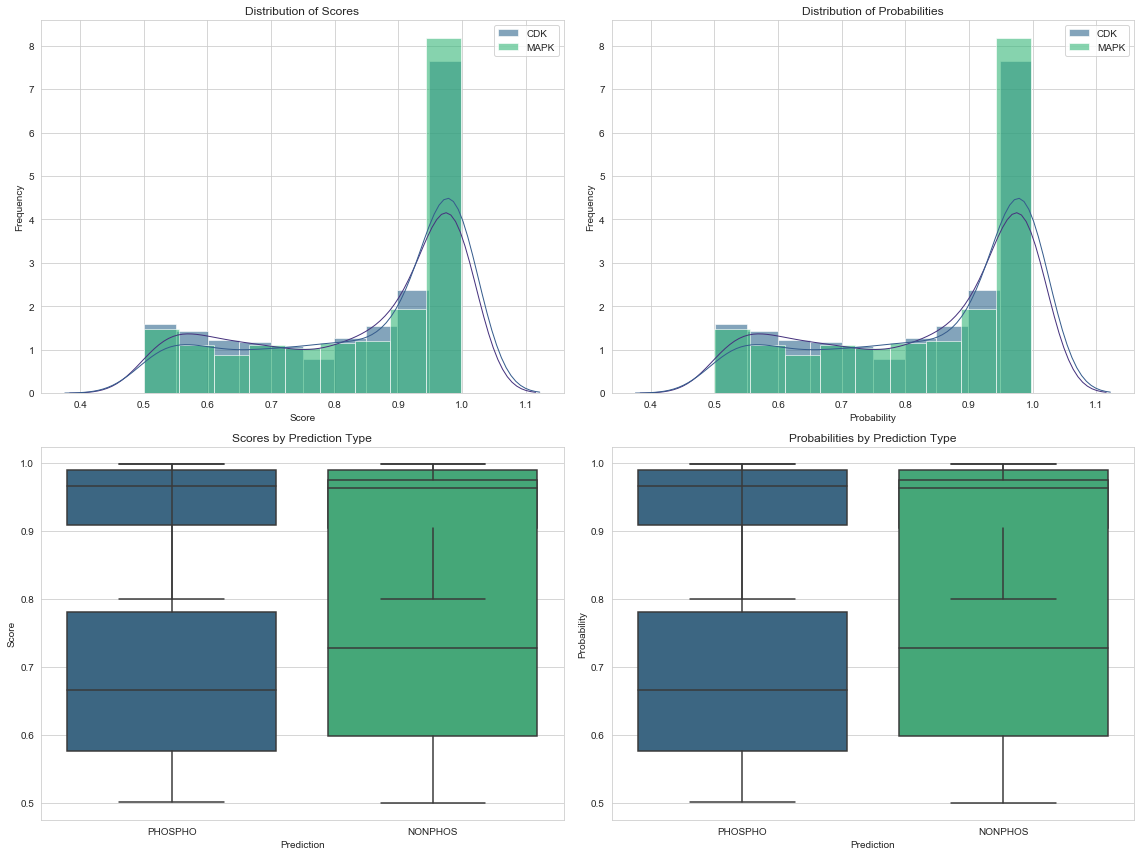

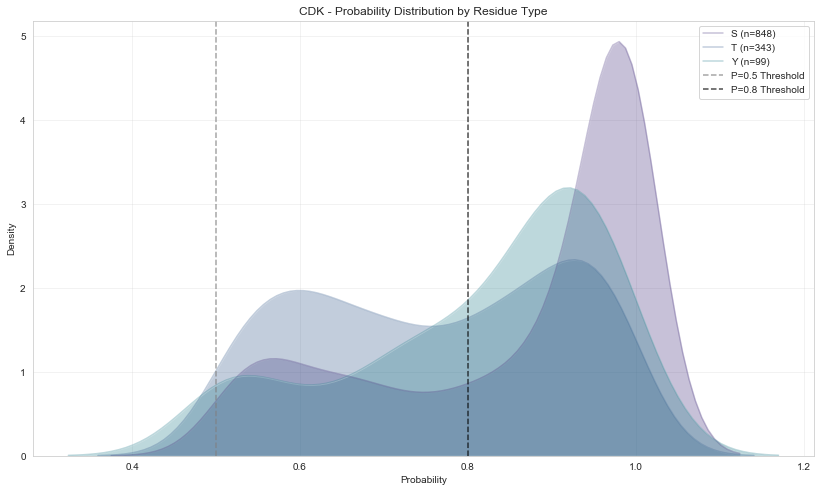

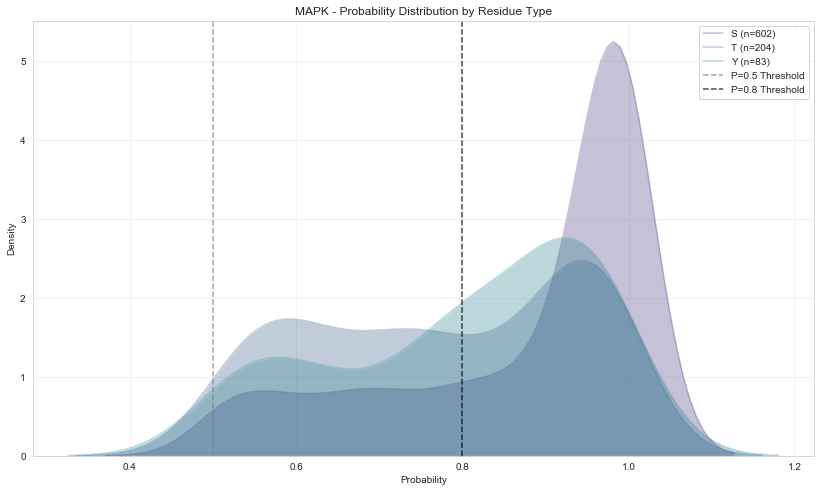

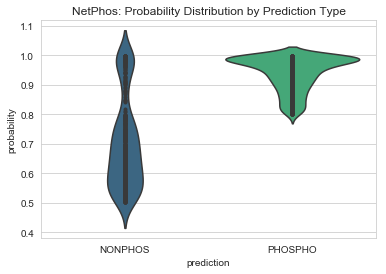


Context patterns for CDK:
S    145
P    137
L    107
T     91
K     90
E     87
V     84
G     76
D     71
A     58

Phosphorylation rate by context for CDK:
   Phosphorylated  Total  Phosphorylation Rate
C            11.0     17              0.647059
G            48.0     76              0.631579
P            84.0    137              0.613139
E            51.0     87              0.586207
M            11.0     19              0.578947
N            22.0     38              0.578947
D            40.0     71              0.563380
K            50.0     90              0.555556
S            79.0    145              0.544828
H            14.0     26              0.538462


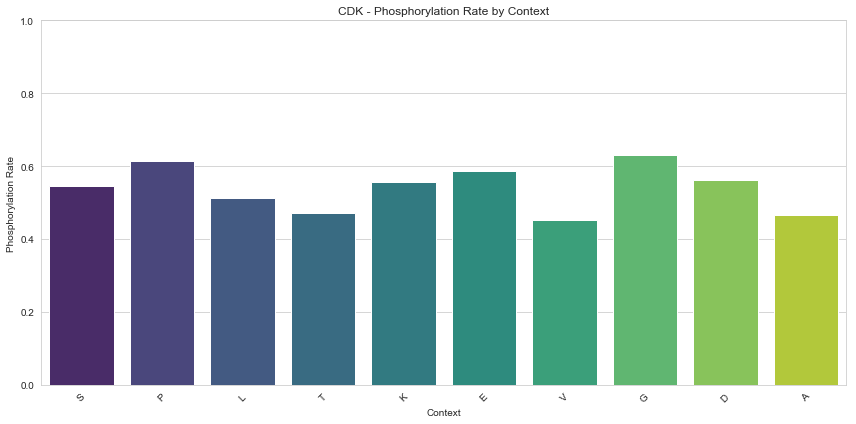

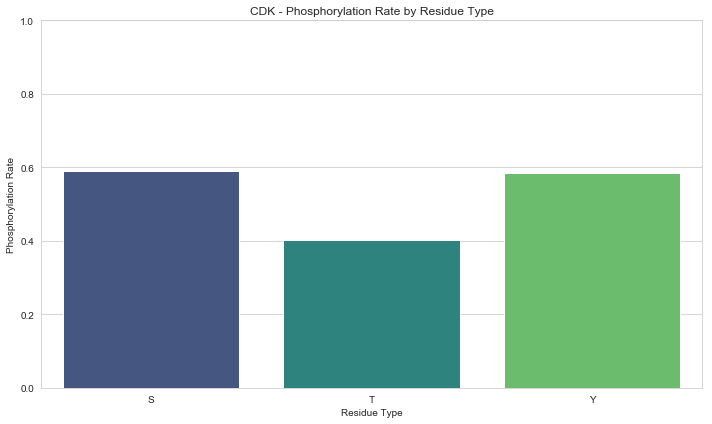


Context patterns for MAPK:
P    132
S    117
E     71
V     68
Q     57
L     56
G     51
A     44
T     43
D     40

Phosphorylation rate by context for MAPK:
         Phosphorylated  Total  Phosphorylation Rate
context                                             
-                     2      2              1.000000
I                    18     27              0.666667
T                    25     43              0.581395
E                    41     71              0.577465
M                     8     14              0.571429
K                    21     38              0.552632
D                    22     40              0.550000
Y                     9     17              0.529412
H                     9     17              0.529412
R                    20     38              0.526316


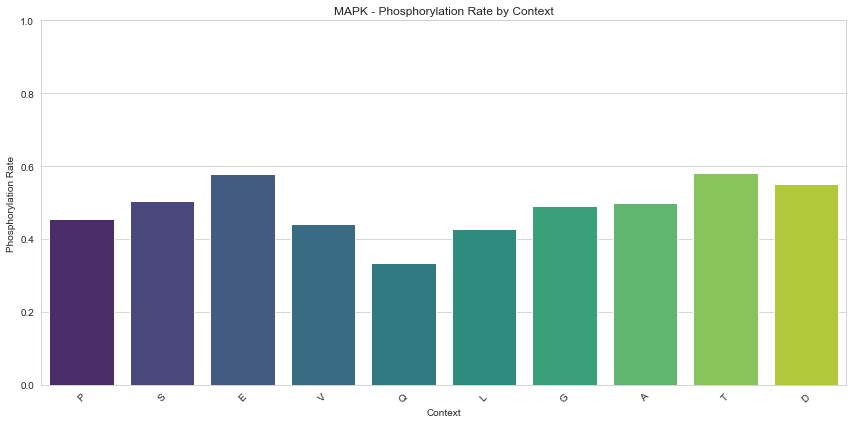

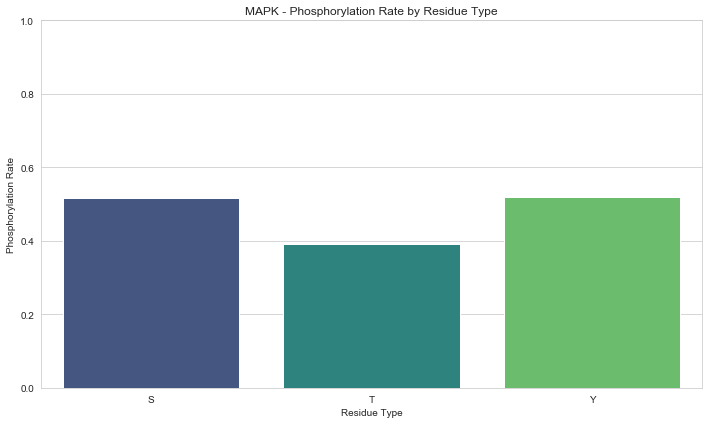

Created network for CDK with 824 nodes and 823 edges


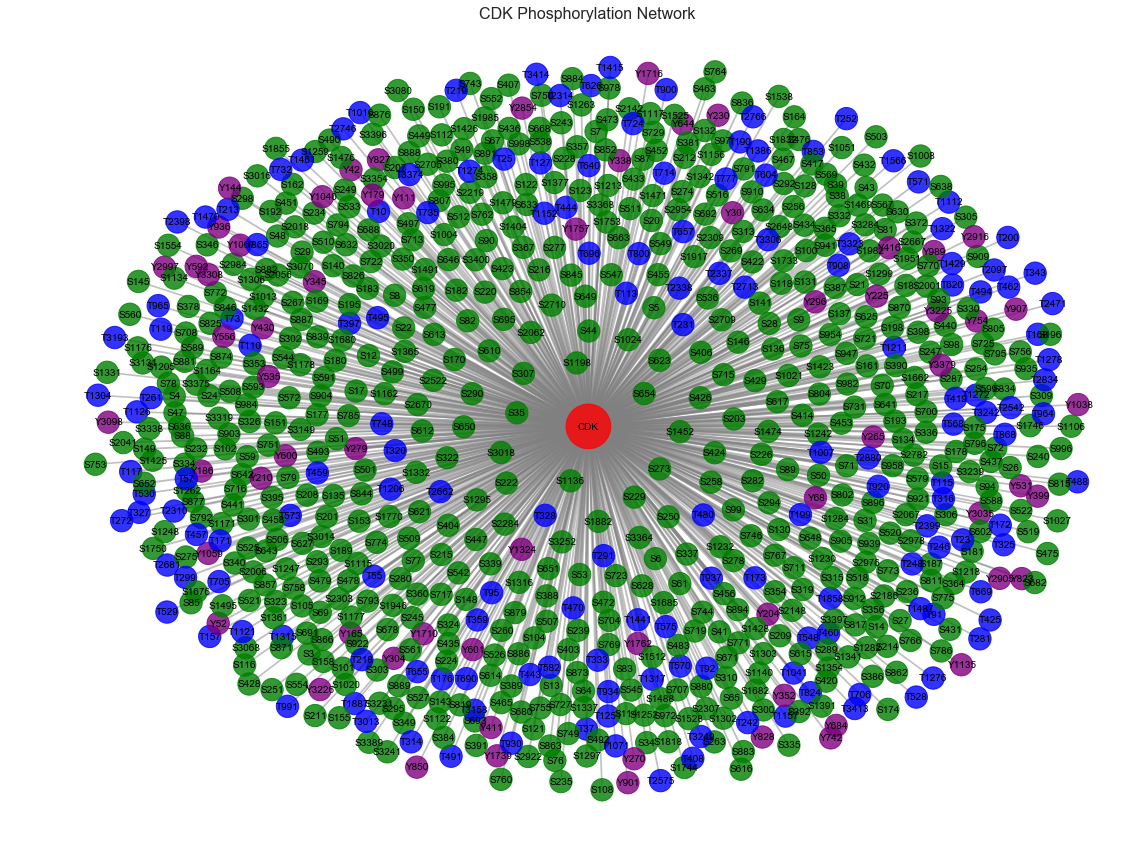

Network Metrics for CDK Phosphorylation Network:
  Average Clustering: 0.0
  Nodes: 824
  Edges: 823
  Connected Components: 1
  Density: 0.00242718446602
High confidence sites by residue type:
  Y: 64
  S: 598
  T: 161
Created network for MAPK with 594 nodes and 593 edges


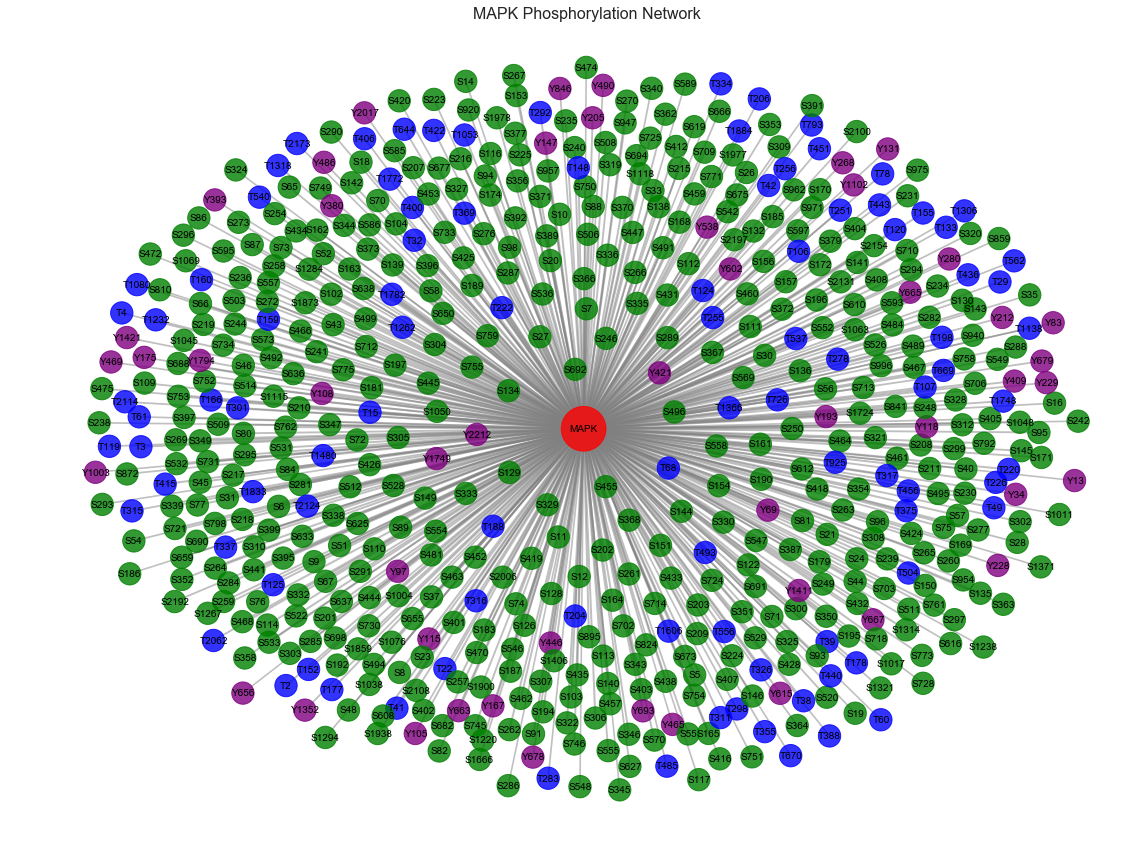

Network Metrics for MAPK Phosphorylation Network:
  Average Clustering: 0.0
  Nodes: 594
  Edges: 593
  Connected Components: 1
  Density: 0.003367003367
High confidence sites by residue type:
  Y: 49
  S: 446
  T: 98

Network Comparison:
     Nodes Edges     Density Average Clustering
CDK    824   823  0.00242718                  0
MAPK   594   593    0.003367                  0


<Figure size 864x432 with 0 Axes>

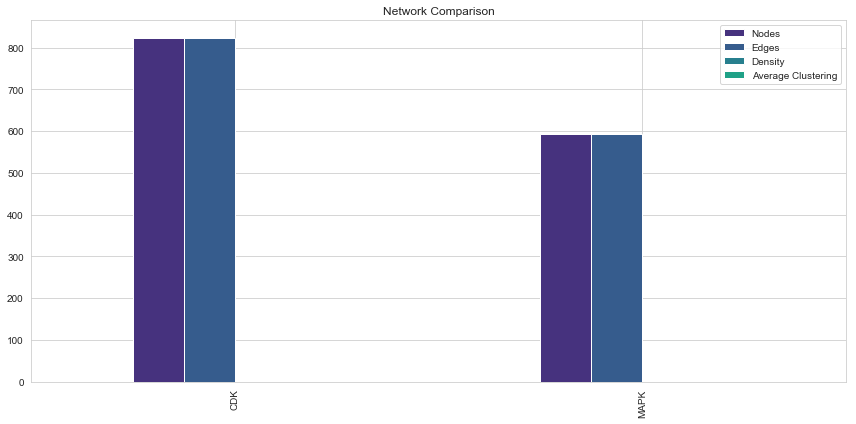

<Figure size 720x432 with 0 Axes>

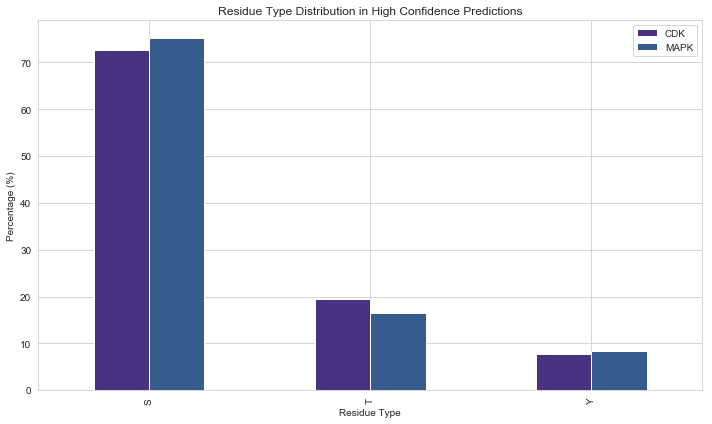


=== Horizontal Features Comparison (Context Patterns) ===
Contexts with biggest difference in phosphorylation rate between CDK and MAPK:
    CDK_count  CDK_phospho_rate Context  Difference  MAPK_count  \
11         38          0.578947       N    0.356725          18   
1          17          0.647059       C    0.202614           9   
12         58          0.517241       Q    0.183908          57   
13        137          0.613139       P    0.158593         132   
17         15          0.533333       W    0.158333           8   
4          76          0.631579       G    0.141383          51   
5          35          0.514286       F    0.105195          22   
10        107          0.514019       L    0.085447          56   
14        145          0.544828       S    0.040554         117   
3          71          0.563380       D    0.013380          40   

    MAPK_phospho_rate  
11           0.222222  
1            0.444444  
12           0.333333  
13           0.454545  
17  

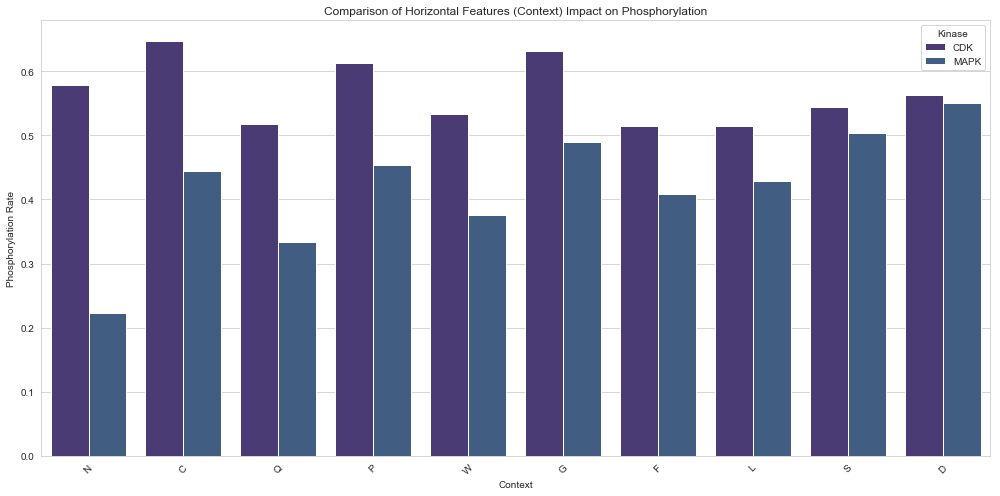


=== Vertical Features Comparison (Residue Types) ===
Residue types with differences in phosphorylation rate between CDK and MAPK:
   CDK_count  CDK_phospho_rate  Difference  MAPK_count  MAPK_phospho_rate  \
0        848          0.589623    0.073011         602           0.516611   
2         99          0.585859    0.067786          83           0.518072   
1        343          0.402332    0.010175         204           0.392157   

  Residue  
0       S  
2       Y  
1       T  


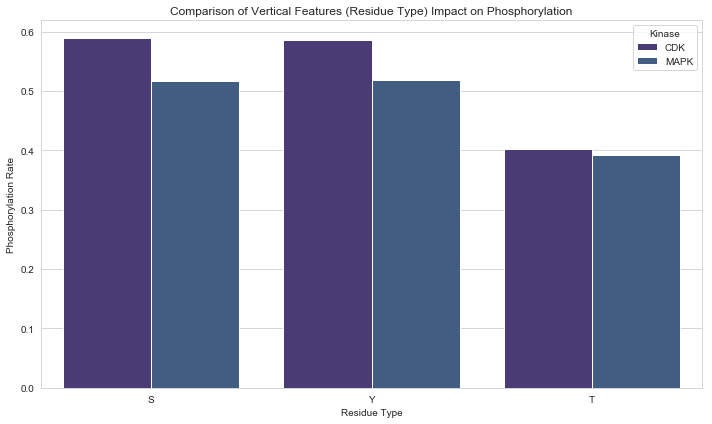


=== Summary of Feature Importance ===
 H/V Ratio  Horizontal Variation Kinase  Vertical Variation
  0.622870              0.054449    CDK            0.087416
  1.655791              0.097718   MAPK            0.059016


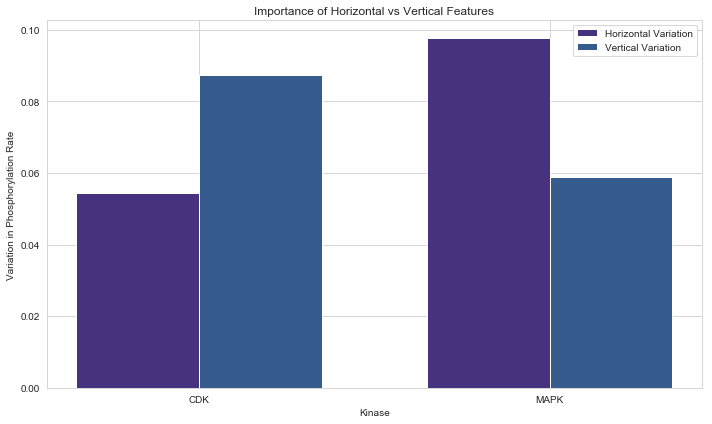

In [148]:
# --- NetPhos Analysis ---
import os, re
import pandas as pd

# Example NetPhos line to parse:
# # sp_O00418_EF2K_HUMAN    18 S   DGGQSPRAG   0.943   p38MAPK    YES
_NETPHOS_RE = re.compile(r'^#\s+(\S+)\s+(\d+)\s+([STY])\s+([A-Z\-]+)\s+([0-9.]+)\s+(\S+)\s+(\S+)$')

def load_netphos_as_phosforus(file_path, yes_as_threshold=True, score_threshold=0.5):
    """
    Parse NetPhos 3.x plain-text output and return a DataFrame compatible with your PHOSforUS analysis:
      columns = ['position','residue_info','prediction','score','probability']
    - residue_info = site residue + +1 residue from the 9-mer context (e.g., 'SP','TP','S-')
    - prediction   = 'PHOSPHO' if Answer == 'YES' (or score >= threshold if yes_as_threshold=False)
    - probability  = NetPhos score (0..1)
    """
    if not os.path.exists(file_path):
        print("File not found: {}".format(file_path))
        return None

    rows = []
    with open(file_path, 'r') as fh:
        for raw in fh:
            line = raw.rstrip("\n")
            if not line or line[0] != '#':
                # skip jobid=..., FASTA header '>', blank lines, etc.
                continue
            m = _NETPHOS_RE.match(line)
            if not m:
                continue
            seq_id, pos, residue, context, score, kinase, answer = m.groups()
            pos = int(pos)
            score = float(score)

            # Build residue_info: site residue + +1 residue from 9-mer context (center at index 4, +1 at 5)
            nxt = '-'
            if len(context) >= 6:
                nxt = context[5]
            residue_info = "{}{}".format(residue, nxt)

            if yes_as_threshold:
                is_phos = (answer.upper() == 'YES')
            else:
                is_phos = (score >= score_threshold)

            prediction  = 'PHOSPHO' if is_phos else 'NONPHOS'
            probability = score

            rows.append([pos, residue_info, prediction, score, probability])

    df = pd.DataFrame(rows, columns=['position','residue_info','prediction','score','probability'])
    print("Loaded NetPhos (as PHOSforUS schema): {}  rows={}".format(file_path, len(df)))
    return df


def collapse_netphos_sites(df):
    """
    Collapse multiple kinase predictions per site to one row with:
      max_score, second_best, margin, n_models, n_above_05, residue_info_of_max
    Assumes df has columns: position, residue_info, score (or probability).
    """
    # we will use 'score' as the numeric field
    if 'score' not in df.columns and 'probability' in df.columns:
        df = df.copy()
        df['score'] = df['probability']

    # index of max per group (to carry residue_info of best-scoring model)
    idx_of_max = df.groupby('position')['score'].idxmax()
    best_rows = df.loc[idx_of_max, ['position', 'residue_info', 'score']].rename(
        columns={'score':'max_score'})

    # second-best and counts
    def second_best(a):
        a = np.asarray(a, dtype=float)
        if a.size < 2:
            return np.nan
        a.sort()
        return a[-2]

    gb = df.groupby('position')['score']
    agg = pd.DataFrame({
        'max_score': gb.max(),
        'second_best': gb.apply(second_best),
        'n_models': gb.size(),
        'n_above_05': gb.apply(lambda x: (x >= 0.5).sum()),
        'n_above_07': gb.apply(lambda x: (x >= 0.7).sum()),
        'n_above_08': gb.apply(lambda x: (x >= 0.8).sum()),
    })
    agg['margin'] = agg['max_score'] - agg['second_best'].fillna(0.0)

    # attach residue_info of the max-scoring row
    agg = agg.merge(best_rows[['position', 'residue_info']].set_index('position'),
                    left_index=True, right_index=True, how='left')

    # final tidy frame similar to PHOSforUS
    collapsed = agg.reset_index()
    collapsed.rename(columns={'index':'position'}, inplace=True)
    return collapsed

def classify_collapsed(collapsed, thr=0.80, min_models=1, use_consensus=False, margin=None):
    """
    Add 'prediction' using stricter rules to avoid 100% calls.
    - thr: numeric cutoff on max_score
    - use_consensus: if True, require n_above_thr >= min_models
    - margin: if set, require (max - second_best) >= margin
    """
    df = collapsed.copy()
    # pick the right consensus column based on thr
    if thr >= 0.8:
        ncol = 'n_above_08'
    elif thr >= 0.7:
        ncol = 'n_above_07'
    else:
        ncol = 'n_above_05'

    pred = (df['max_score'] >= thr)
    if use_consensus:
        pred = pred & (df[ncol] >= int(min_models))
    if margin is not None:
        pred = pred & (df['margin'] >= float(margin))

    df['prediction']  = np.where(pred, 'PHOSPHO', 'NONPHOS')
    # keep PHOSforUS-like columns your pipeline expects
    df['probability'] = df['max_score']
    df['score']       = df['max_score']
    # residue_info already present
    return df[['position','residue_info','prediction','score','probability']]


# Load NetPhos (your adapter) WITHOUT forcing a 0.5 decision
cdk_raw  = load_netphos_as_phosforus('CDK_netphos.txt', yes_as_threshold=False, score_threshold=0.0)
mapk_raw = load_netphos_as_phosforus('MAPK_netphos.txt', yes_as_threshold=False, score_threshold=0.0)

# Collapse to one row per position
cdk_collapsed  = collapse_netphos_sites(cdk_raw)
mapk_collapsed = collapse_netphos_sites(mapk_raw)

# Classify with stricter settings (tune these to match PHOSforUS rates)
cdk_results  = classify_collapsed(cdk_collapsed,  thr=0.80, min_models=1, use_consensus=False, margin=0.05)
mapk_results = classify_collapsed(mapk_collapsed, thr=0.80, min_models=1, use_consensus=False, margin=0.05)

# Reuse existing analysis exactly as-is:
cdk_stats  = analyze_result_stats(cdk_results,  'CDK')
mapk_stats = analyze_result_stats(mapk_results, 'MAPK')

from tabulate import tabulate
print("\nCDK Statistics:")
print(tabulate(cdk_stats.T, headers=["Metric", "Value"], tablefmt="grid"))

print("\nMAPK Statistics:")
print(tabulate(mapk_stats.T, headers=["Metric", "Value"], tablefmt="grid"))

# Side-by-side comparison
combined_stats = pd.concat([cdk_stats, mapk_stats])
print("\nComparison of CDK and MAPK Statistics:\n")
print(tabulate(combined_stats.T, headers=["Metric", "CDK", "MAPK"], tablefmt="grid", showindex=True))

# 3) Distributions
plot_score_distributions([cdk_results, mapk_results], ['CDK', 'MAPK'])

# 4) Context & residue analysis
cdk_residue_stats  = extract_sequence_context(cdk_results,  'CDK')
mapk_residue_stats = extract_sequence_context(mapk_results, 'MAPK')

# 5) Networks
cdk_network  = create_protein_network(cdk_results,  'CDK',  confidence_threshold=0.8)
visualize_network(cdk_network,  'CDK Phosphorylation Network')

mapk_network = create_protein_network(mapk_results, 'MAPK', confidence_threshold=0.8)
visualize_network(mapk_network, 'MAPK Phosphorylation Network')

# 6) Network comparison
compare_networks([cdk_network, mapk_network], ['CDK', 'MAPK'])

# 7) Feature-type comparison (build feature dicts and plot)
cdk_features, mapk_features = compare_feature_types(cdk_results, mapk_results)

# 8) Summary of feature-importance variability
summary_df = summarize_feature_importance(cdk_features, mapk_features)


In [149]:
# Check numbers
# PHOSforUS (full)
cdk_phos = load_phosfor_results('CDKresults.txt')
mapk_phos = load_phosfor_results('MAPKresults.txt')

# NetPhos (collapsed + classified as you set earlier)
cdk_net_raw  = load_netphos_as_phosforus('CDK_netphos.txt', yes_as_threshold=False, score_threshold=0.0)
mapk_net_raw = load_netphos_as_phosforus('MAPK_netphos.txt', yes_as_threshold=False, score_threshold=0.0)
cdk_net_collapsed  = collapse_netphos_sites(cdk_net_raw)
mapk_net_collapsed = collapse_netphos_sites(mapk_net_raw)
cdk_net  = classify_collapsed(cdk_net_collapsed,  thr=0.80, margin=0.05)  
mapk_net = classify_collapsed(mapk_net_collapsed, thr=0.80, margin=0.05)

# print("PHOSforUS total sites (CDK):", len(cdk_phos))
# print("NetPhos   total sites (CDK):", len(cdk_net))

# 2) To get a FAIR overlap comparison align to shared positions
def align_on_positions(phos_df, net_df):
    keep_pos = set(net_df['position'].unique())
    phos_aligned = phos_df[phos_df['position'].isin(keep_pos)].copy()
    return phos_aligned

cdk_phos_aligned = align_on_positions(cdk_phos, cdk_net)
mapk_phos_aligned = align_on_positions(mapk_phos, mapk_net)

# print("Aligned PHOSforUS (CDK) sites:", len(cdk_phos_aligned))
# print("NetPhos         (CDK) sites:", len(cdk_net))

# 3) Quick composition check
for name, df in [('PHOSforUS-CDK (aligned)', cdk_phos_aligned),
                 ('NetPhos-CDK', cdk_net)]:
    print("\n{} site composition:".format(name))
    print(df['residue_info'].str[0].value_counts())

# 4) Merge to inspect site-by-site differences
def merge_tools(phos_df, net_df):
    ph = phos_df[['position','residue_info','probability','prediction']].copy()
    ph.columns = ['position','residue_info_ph','p_prob','p_pred']
    ne = net_df[['position','residue_info','probability','prediction']].copy()
    ne.columns = ['position','residue_info_net','n_prob','n_pred']
    m = pd.merge(ph, ne, on='position', how='inner')
    m['prob_delta'] = m['n_prob'] - m['p_prob']
    m['agree'] = (m['p_pred'] == m['n_pred'])
    return m

cdk_cmp = merge_tools(cdk_phos_aligned, cdk_net)
mapk_cmp = merge_tools(mapk_phos_aligned, mapk_net)

print("\nCDK agreement rate:", float(cdk_cmp['agree'].sum())/len(cdk_cmp) if len(cdk_cmp) else float('nan'))
print("MAPK agreement rate:", float(mapk_cmp['agree'].sum())/len(mapk_cmp) if len(mapk_cmp) else float('nan'))


Loaded: CDKresults.txt
Number of records:  3832
Data columns: ['position', 'residue_info', 'prediction', 'score', 'probability']
Loaded: MAPKresults.txt
Number of records:  3619
Data columns: ['position', 'residue_info', 'prediction', 'score', 'probability']
Loaded NetPhos (as PHOSforUS schema): CDK_netphos.txt  rows=4239
Loaded NetPhos (as PHOSforUS schema): MAPK_netphos.txt  rows=4112

PHOSforUS-CDK (aligned) site composition:
S    1872
T    1122
Y     477
Name: residue_info, dtype: int64

NetPhos-CDK site composition:
S    848
T    343
Y     99
Name: residue_info, dtype: int64

CDK agreement rate: 0.520887352348
MAPK agreement rate: 0.505757307352


# MusiteDeep Tutorial Section:

Command:<br>
cd ~/MusiteDeep/MusiteDeep/<br><br>
python ./predict.py \
  -input testing_proteins_CDK.fasta \
  -predict-type kinase \
  -kinase CDK \
  -residue-types S,T,Y \
  -output testing_CDK_predictions.tsv

Done predicting by model of class 0 and initial class 0 <br>
Done predicting by model of class 1 and initial class 0 <br>
Done predicting by model of class 2 and initial class 0 <br>
Done predicting by model of class 0 and initial class 1 <br>
Done predicting by model of class 1 and initial class 1 <br>
Done predicting by model of class 2 and initial class 1 <br>
Done predicting by model of class 0 and initial class 2 <br>
Done predicting by model of class 1 and initial class 2 <br>
Done predicting by model of class 2 and initial class 2 <br>
Done predicting by model of class 0 and initial class 3 <br>
Done predicting by model of class 1 and initial class 3 <br>
Done predicting by model of class 2 and initial class 3 <br>
Done predicting by model of class 0 and initial class 4 <br>
Done predicting by model of class 1 and initial class 4 <br>
Done predicting by model of class 2 and initial class 4 <br>
Successfully predicted for CDK !

Written: testing_CDK_predictions.tsv_CDK.txt


python ./predict.py \
  -input testing_proteins_MAPK.fasta \
  -predict-type kinase \
  -kinase MAPK \
  -residue-types S,T,Y \
  -output testing_MAPK_predictions.tsv

Done predicting by model of class 0 and initial class 0 <br>
Done predicting by model of class 1 and initial class 0 <br>
Done predicting by model of class 2 and initial class 0 <br>
Done predicting by model of class 0 and initial class 1 <br>
Done predicting by model of class 1 and initial class 1 <br>
Done predicting by model of class 2 and initial class 1 <br>
Done predicting by model of class 0 and initial class 2 <br>
Done predicting by model of class 1 and initial class 2 <br>
Done predicting by model of class 2 and initial class 2 <br>
Done predicting by model of class 0 and initial class 3 <br>
Done predicting by model of class 1 and initial class 3 <br>
Done predicting by model of class 2 and initial class 3 <br>
Done predicting by model of class 0 and initial class 4 <br>
Done predicting by model of class 1 and initial class 4 <br>
Done predicting by model of class 2 and initial class 4 <br>
Successfully predicted for MAPK !

Written: testing_MAPK_predictions.tsv_MAPK.txt



CDK (MusiteDeep) Statistics:
+--------------------------+----------------+
| Metric                   |          Value |
+==========================+================+
| Max Probability          |    0.992266    |
+--------------------------+----------------+
| Mean Probability         |    0.0593392   |
+--------------------------+----------------+
| Mean Score               |    0.0593392   |
+--------------------------+----------------+
| Min Probability          |    9.44225e-11 |
+--------------------------+----------------+
| Non-phosphorylated Sites | 3127           |
+--------------------------+----------------+
| Phosphorylated Sites     |  140           |
+--------------------------+----------------+
| Phosphorylation Rate     |    0.0428528   |
+--------------------------+----------------+
| S Phosphorylated         |   88           |
+--------------------------+----------------+
| S Phosphorylation Rate   |    0.0436292   |
+--------------------------+----------------+
| S 

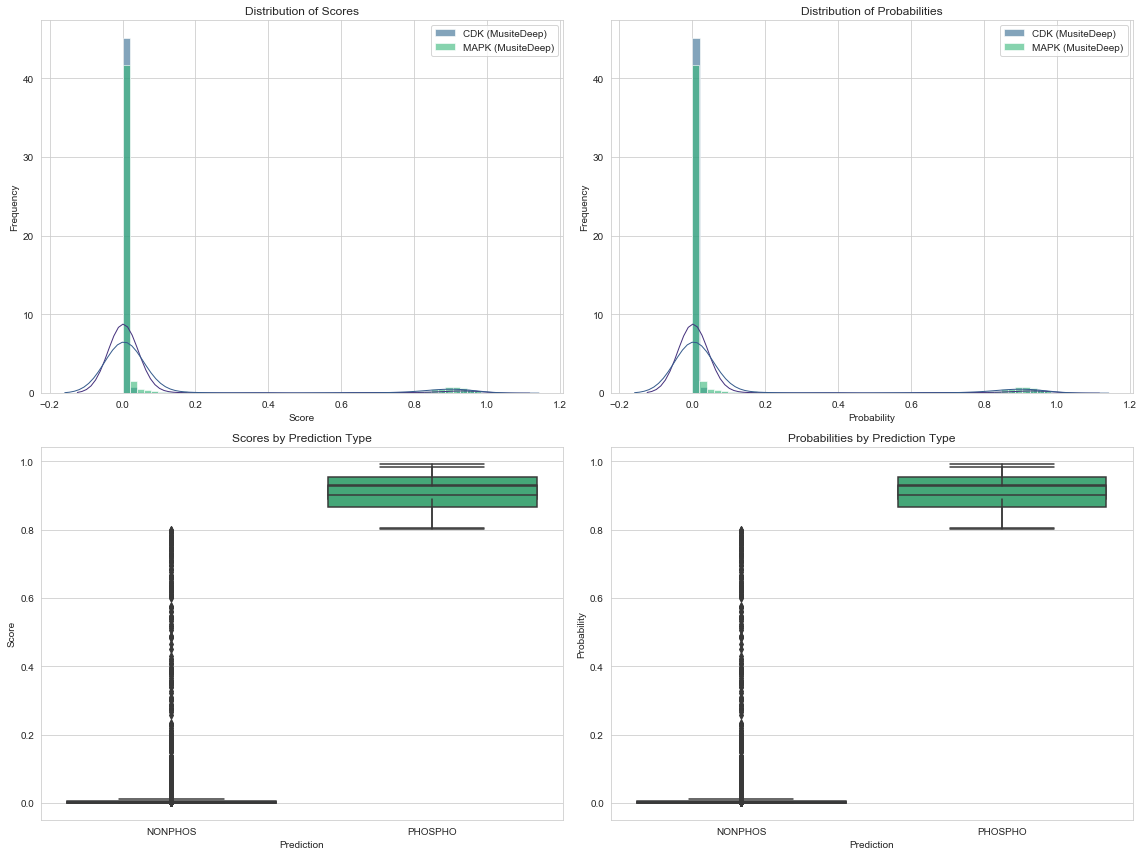

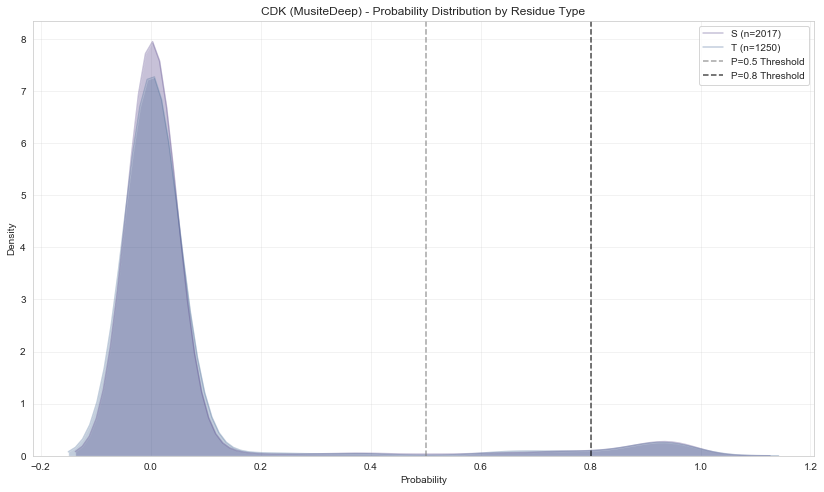

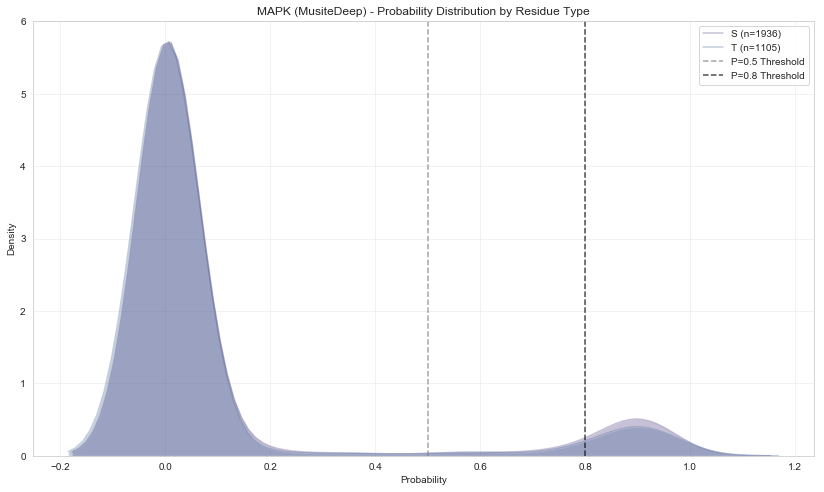


Context patterns for CDK (MusiteDeep):
-    3267

Phosphorylation rate by context for CDK (MusiteDeep):
         Phosphorylated  Total  Phosphorylation Rate
context                                             
-                   140   3267              0.042853


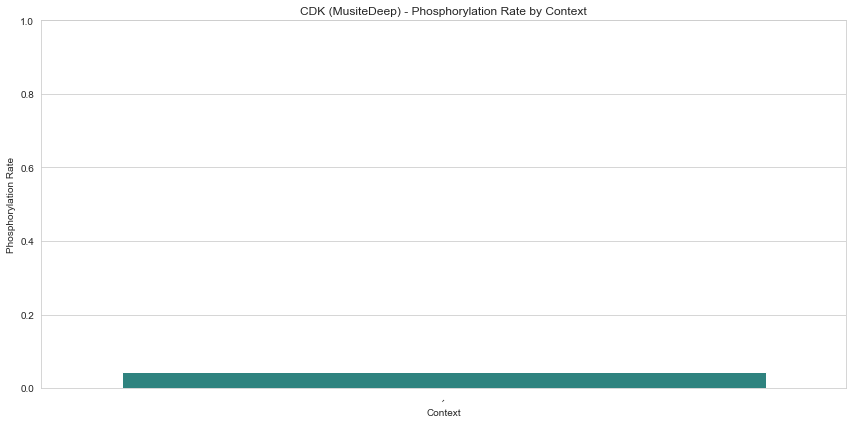

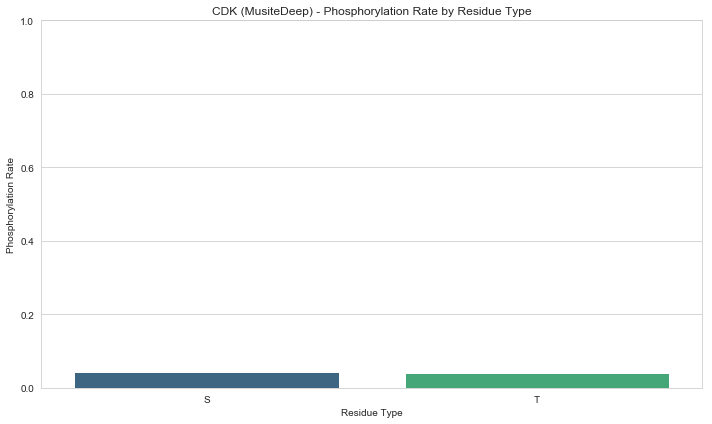


Context patterns for MAPK (MusiteDeep):
-    3041

Phosphorylation rate by context for MAPK (MusiteDeep):
         Phosphorylated  Total  Phosphorylation Rate
context                                             
-                   260   3041              0.085498


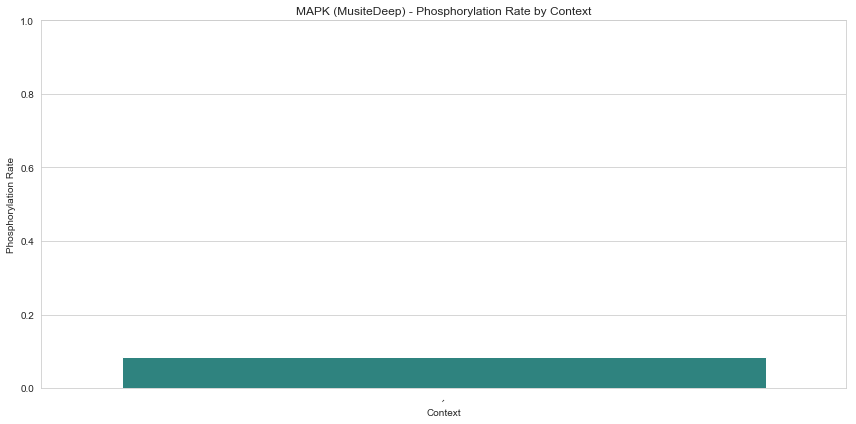

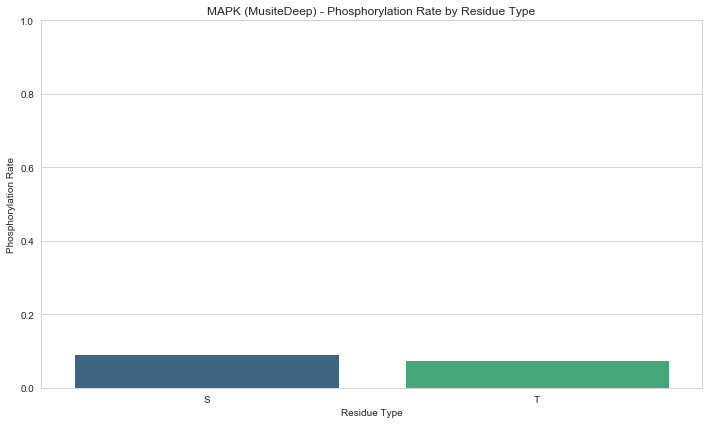

Created network for CDK (MusiteDeep) with 136 nodes and 135 edges


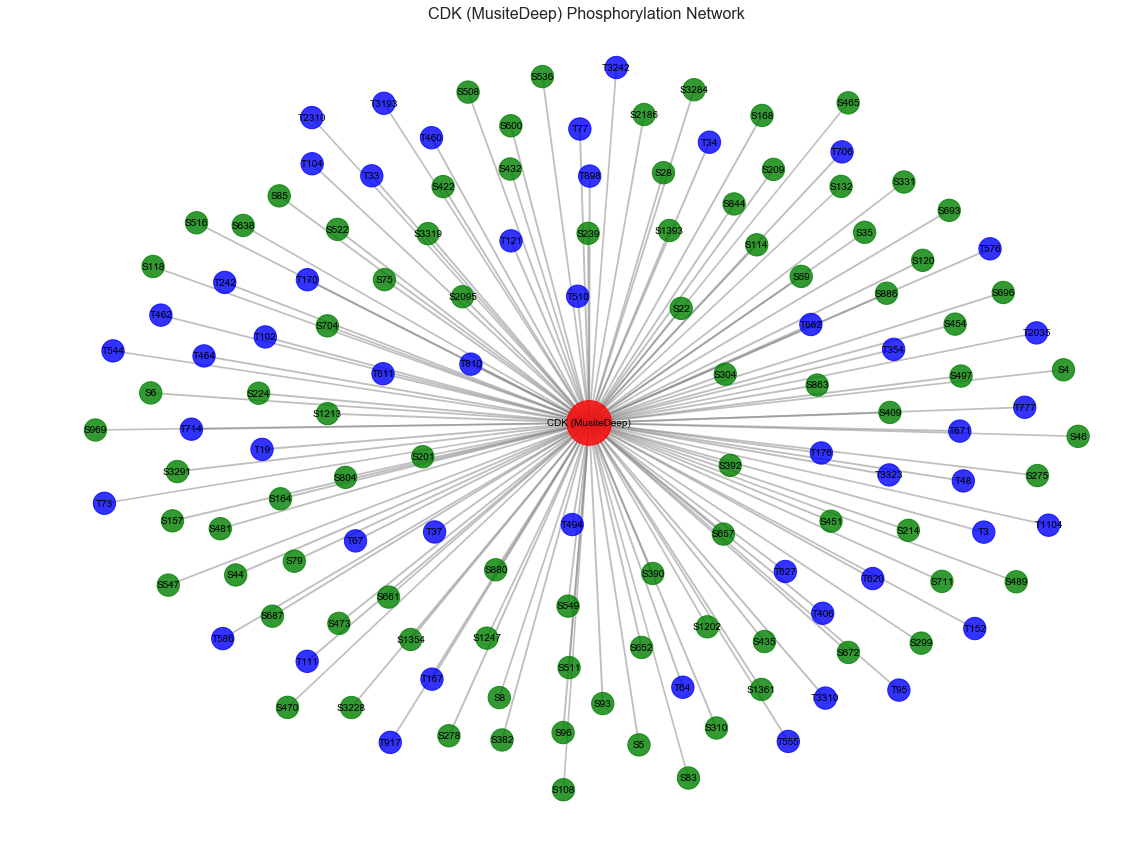

Network Metrics for CDK (MusiteDeep) Phosphorylation Network:
  Average Clustering: 0.0
  Nodes: 136
  Edges: 135
  Connected Components: 1
  Density: 0.0147058823529
High confidence sites by residue type:
  S: 86
  T: 49
Created network for MAPK (MusiteDeep) with 221 nodes and 220 edges


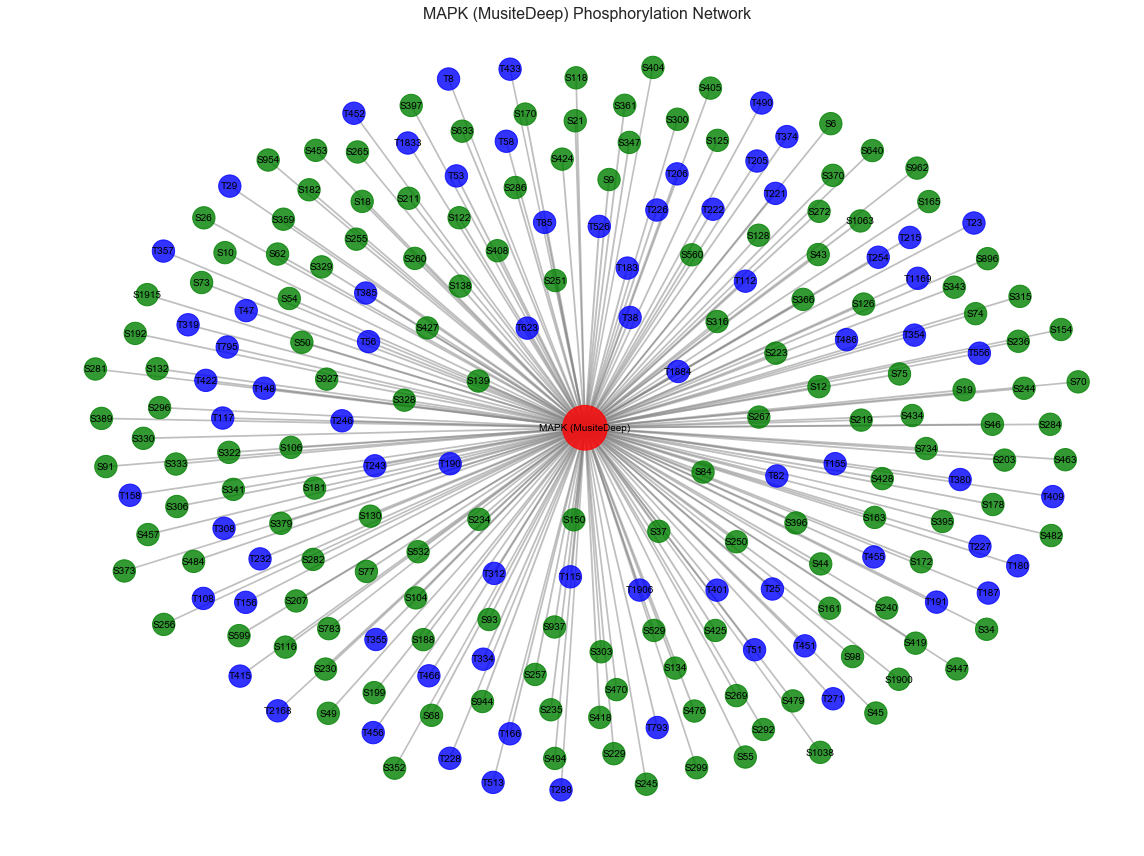

Network Metrics for MAPK (MusiteDeep) Phosphorylation Network:
  Average Clustering: 0.0
  Nodes: 221
  Edges: 220
  Connected Components: 1
  Density: 0.00904977375566
High confidence sites by residue type:
  S: 147
  T: 73

Network Comparison:
                  Nodes Edges     Density Average Clustering
CDK (MusiteDeep)    136   135   0.0147059                  0
MAPK (MusiteDeep)   221   220  0.00904977                  0


<Figure size 864x432 with 0 Axes>

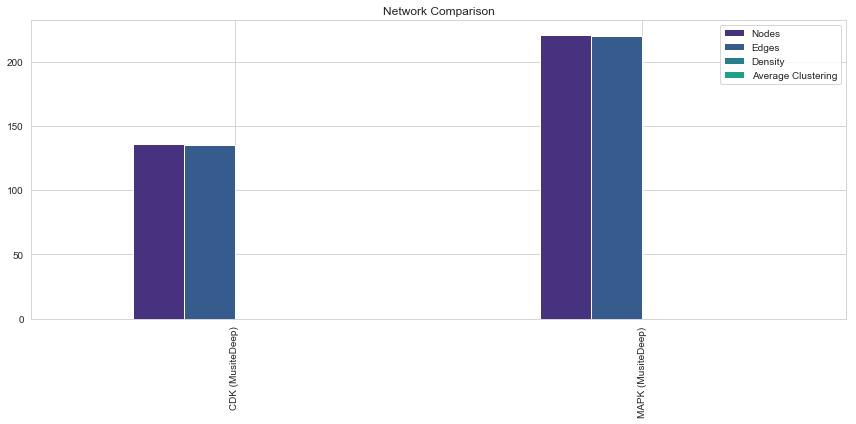

<Figure size 720x432 with 0 Axes>

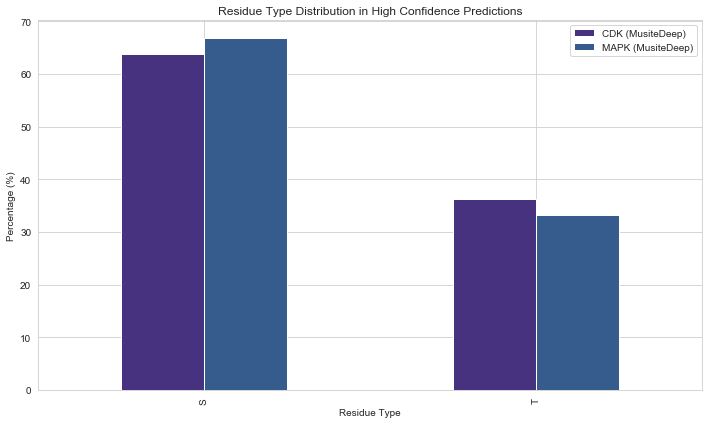

In [165]:
# --- MusiteDeep Analysis ---

BASE = "/Users/val/Projects/Protein-Bioinformatics/VL09_PTM-Networks"
CDK_FILE  = os.path.join(BASE, "testing_CDK_predictions.tsv_CDK.txt")
MAPK_FILE = os.path.join(BASE, "testing_MAPK_predictions.tsv_MAPK.txt")
FASTA_CDK  = os.path.join(BASE, "testing_proteins_CDK.fasta")
FASTA_MAPK = os.path.join(BASE, "testing_proteins_MAPK.fasta")
THR = 0.80

def read_fasta_dict(fpath):
    seqs, cur_id, buf = {}, None, []
    if not os.path.exists(fpath):
        return seqs
    for line in open(fpath):
        line = line.strip()
        if not line: continue
        if line.startswith(">"):
            if cur_id is not None:
                seqs[cur_id] = ''.join(buf).upper()
            cur_id = line[1:].split()[0]
            buf = []
        else:
            buf.append(line)
    if cur_id is not None:
        seqs[cur_id] = ''.join(buf).upper()
    return seqs

def load_musitedeep_as_phosforus(path, fasta_path=None):
    # Try TSV with no header; MusiteDeep sometimes writes 4 columns: id, position, residue, probability
    try:
        df = pd.read_csv(path, sep='\t', header=None, engine='python')
    except Exception:
        # Fallback: any whitespace
        df = pd.read_csv(path, delim_whitespace=True, header=None, engine='python')

    # Expect at least 4 columns; keep the first four
    cols = df.columns.tolist()
    if len(cols) < 4:
        raise ValueError("Unexpected file format (need >=4 columns): %s" % path)
    df = df.iloc[:, :4]
    df.columns = ['id_raw', 'position', 'residue', 'probability']

    # Normalize types
    df['position'] = pd.to_numeric(df['position'], errors='coerce')
    df['probability'] = pd.to_numeric(df['probability'], errors='coerce')
    df = df.dropna(subset=['position', 'probability']).copy()
    df['position'] = df['position'].astype(int)
    df['residue'] = df['residue'].astype(str).str[0].str.upper()

    # Make an ID that matches your FASTA: first token after '>'
    # Example: "sp|P10275|ANDR_HUMAN Androgen receptor ..." -> "sp|P10275|ANDR_HUMAN"
    df['id'] = df['id_raw'].astype(str).str.split().str[0]

    # Build residue_info: <residue><+1> using FASTA (optional but recommended)
    seqs = read_fasta_dict(fasta_path) if fasta_path else {}
    next_residues = []
    for _, row in df.iterrows():
        rid = str(row['id'])
        nxt = '-'
        if rid in seqs:
            seq = seqs[rid]
            i = int(row['position']) - 1  # 1-based -> 0-based
            if i + 1 < len(seq):
                nxt = seq[i + 1]
        next_residues.append(nxt)
    df['residue_info'] = df['residue'] + pd.Series(next_residues)

    # Decision column to match your PHOSforUS schema
    df['score'] = df['probability']
    df['prediction'] = np.where(df['probability'] >= THR, 'PHOSPHO', 'NONPHOS')

    # Final schema
    keep = ['position', 'residue_info', 'prediction', 'score', 'probability', 'id', 'residue']
    return df[keep]


# --- Load both kinase outputs ---
cdk_results  = load_musitedeep_as_phosforus(CDK_FILE,  fasta_path=FASTA_CDK)
mapk_results = load_musitedeep_as_phosforus(MAPK_FILE, fasta_path=FASTA_MAPK)

# --- Run your existing analysis utilities ---
cdk_stats  = analyze_result_stats(cdk_results,  'CDK (MusiteDeep)')
mapk_stats = analyze_result_stats(mapk_results, 'MAPK (MusiteDeep)')

from tabulate import tabulate
print("\nCDK (MusiteDeep) Statistics:")
print(tabulate(cdk_stats.T, headers=["Metric", "Value"], tablefmt="grid"))

print("\nMAPK (MusiteDeep) Statistics:")
print(tabulate(mapk_stats.T, headers=["Metric", "Value"], tablefmt="grid"))

# Side-by-side comparison
combined_stats = pd.concat([cdk_stats, mapk_stats])
print("\nComparison of CDK and MAPK (MusiteDeep) Statistics:\n")
print(tabulate(combined_stats.T, headers=["Metric", "CDK", "MAPK"], tablefmt="grid", showindex=True))

plot_score_distributions([cdk_results, mapk_results],
                         ['CDK (MusiteDeep)', 'MAPK (MusiteDeep)'])

cdk_residue_stats  = extract_sequence_context(cdk_results,  'CDK (MusiteDeep)')
mapk_residue_stats = extract_sequence_context(mapk_results, 'MAPK (MusiteDeep)')

cdk_network  = create_protein_network(cdk_results,  'CDK (MusiteDeep)',  confidence_threshold=THR)
visualize_network(cdk_network,  'CDK (MusiteDeep) Phosphorylation Network')

mapk_network = create_protein_network(mapk_results, 'MAPK (MusiteDeep)', confidence_threshold=THR)
visualize_network(mapk_network, 'MAPK (MusiteDeep) Phosphorylation Network')

compare_networks([cdk_network, mapk_network],
                 ['CDK (MusiteDeep)', 'MAPK (MusiteDeep)'])


<!-- RESULTS & ANALYSIS SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Results & Analysis
  </h2>

  <!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Weak Correlation Between Predicted and Measured ddG:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    Stuff
  </p>

<!-- DELIVERABLES SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Lab Deliverables
  </h2>

  <!-- Question 1-->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
    How do platforms like Netphos or Musite perform predictions? How does PHOSforUS differ?
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    <b>1. PHOSforUS </b>
      <br>
PHOSforUS predicts phosphorylation by integrating sequence motifs, local structural propensities, and biophysical signatures associated with disorder and post-translational regulation (Choa et al., 2020). Unlike purely sequence-based neural models, PHOSforUS explicitly builds on the idea that phosphorylation sites cluster in intrinsically disordered regions, which provide the flexibility required for kinase access and signaling function. The algorithm extracts local windows around each residue and calculates structural features such as disorder probability, secondary-structure likelihood, charge distribution, and predicted flexibility, combining them into a logistic regression or ensemble-style classifier tuned separately for S, T, and Y. This emphasis on physicochemical context, rather than relying only on amino acid sequences, allows PHOSforUS to prioritize biologically meaningful signals that align with known phosphorylation mechanisms (Choa et al., 2020). PHOSforUS outputs probabilities and tends to produce smoother score distributions that reflect structural accessibility rather than only motif enrichment.
<br><br>
<b>2. NetPhos</b>
<br><br>
NetPhos uses shallow neural networks trained on experimentally verified phosphorylation sites to detect short sequence motifs characteristic of kinase recognition (Biswas et al., 2010). It represents an early generation of machine-learning predictors, each phosphorylation candidate is encoded as a fixed-length amino acid window centered on the residue of interest, and the neural network learns residue preferences, position-specific weights, and motif patterns associated with phosphorylation in curated datasets. Because the model is relatively small, it is interpretable and fast, but does not account for long-range interactions, disordered regions, or tertiary structure. NetPhos outputs separate predictions for different kinase families but often provides multiple scores per site, which users later collapse or average. Despite its age, NetPhos remains a benchmark because its motif-based learning captures many canonical kinase signatures that modern deep learning models also rediscover.
<br><br>
<b>3. MusiteDeep</b>
<br><br>
MusiteDeep represents the deep-learning generation of phosphorylation prediction. It applies convolutional neural networks (CNNs) and bidirectional recurrent networks (LSTMs/GRUs) to automatically extract hierarchical sequence features without manual motif engineering (Wang et al., 2017). The CNN layers capture short local motifs—analogous to NetPhos—but the recurrent layers capture long-range dependencies and contextual patterns across the entire protein. MusiteDeep uses large phosphorylation datasets (PhosphoSitePlus, UniProtKB, etc.), enabling the model to learn general STY phosphorylation signatures as well as kinase-specific profiles. Importantly, MusiteDeep outputs raw sigmoid scores, which are not probability-calibrated; they tend to be numerically lower but still reflect meaningful ranking. Because deep networks learn both linear motifs and nonlinear compositional features, MusiteDeep typically achieves higher sensitivity on diverse proteins, including those lacking canonical motifs. However, the interpretability of predictions is lower than older motif-based methods.<br><br>
  </p>

  <!-- How does each handle FASTA data-->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
How does each program handle FASTA data?
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    <b>PHOSforUS (structural + sequence-based classification)</b><br>
      1. Parses the amino acid sequence and identifies all S, T, and Y residues.<br>
      2. For each residue, PHOSforUS extracts a local sequence window (e.g., 29–31 aa)<br>
      3. It then computes biophysical and structural features: predicted disorder, secondary-structure propensity, charge patterning (κ, pI, local net charge), flexibility and coil likelihood, conservation and motif tendencies<br>
      4. These features are fed into a logistic regression / ensemble classifier tuned separately for S, T, and Y.<br>
      5. Output for each S/T/Y site: Probability of phosphorylation ( ≥0.5 for likely sites), structural context labels, and functional interpretation (e.g., “disordered hotspot”)<br>
<br><br>
<b>NetPhos (motif-recognizing neural network)</b><br>
      1. Reads your FASTA and identifies all S, T, Y residues.<br>
      2. For each site, extracts a short fixed-length sequence window (often 9 or 11 aa).<br>
      3. Encodes each position using one-hot representations (20 amino acids → 20-dimensional vector).<br>
      4. Passes this window into a shallow feed-forward neural network trained on known phosphorylation motifs.<br>
      5. The network learns preferences like RxxS, SP, TP, etc.<br>
      6. Outputs for each site: A score between ~0.5–1.0 for predicted phosphorylation; May give multiple predictions per site (e.g., p38 MAPK, CDK, GSK3)<br>
<br><br>
<b>MusiteDeep (deep CNN + RNN sequence learner)</b><br>
      1. Reads FASTA and identifies all S/T/Y sites.<br>
      2. Converts the entire protein into a learnable sequence embedding<br>
      3.  Convolutional layers used to detect short motifs (like NetPhos) and Recurrent layers (LSTM/GRU) used to integrate long-range sequence dependence<br>
      4. Learns both local motifs and broader context (e.g., patterns far from the site).<br>
      5. Outputs: A sigmoid score for each S/T/Y residue (usually 0.0–0.3 for general model). These are not calibrated probabilities, but ranking indicators. For kinase-specific models (CDK, MAPK): Same pipeline, but trained on subsets of experimentally validated kinase targets. Requires specifying -predict-type kinase and -kinase CDK or MAPK.<br>
<br><br>
In Practice: <br>
PHOSforUS cares where the residue sits structurally, not just the motif around it <br>
NetPhos is almost entirely motif-driven <br>
MusiteDeep is the most flexible model, learning complex contextual patterns, but output scores are lower and require a lower threshold (~0.25–0.35)<br><br>
  </p>

 <!-- Question 2-->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
Why do you think PHOSforUS results in more predicted phosphorylated proteins in datasets, compared to Netphos or Musite?
  </h3>
  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
      PHOSforUS typically yields higher phosphorylation rates than NetPhos or MusiteDeep because it is built on fundamentally different assumptions about what makes a residue phosphorylatable. While NetPhos and MusiteDeep rely primarily on motif learning from sequence, PHOSforUS incorporates structural and biophysical features that naturally classify many residues as potentially phosphorylatable even when their local motif is weak. PHOSforUS is designed around intrinsic disorder. PHOSforUS treats disorder as a positive determinant, so if a residue lies in a predicted disordered region, and has favorable flexibility/charge, the model assigns a high phosphorylation probability even without a strong motif. PHOSforUS will call many S/T/Y residues as phospho-competent simply because they are structurally accessible. NetPhos and MusiteDeep do not use disorder as a primary feature, so they don't systematically boost scores for IDRs.
  </p>

<!-- REFERENCES SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    References
  </h2>

  <!-- WebBased Tools -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Web-Based Tools:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6;">
   <b>NetPhos</b><br>
      NetPhos 3.1 - DTU Health Tech - Bioinformatic Services. (2025). https://services.healthtech.dtu.dk/services/NetPhos-3.1/<br><br>
      <b>MusiteDeep</b><br>
      MusiteDeep. (2025). https://www.musite.net/
  </p>

  <!-- Repositories -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Git:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6;">
    <b>PHOSforUS</b><br>
      bxlab/PHOSforUS: Github repository for PHOSforUS predictor distribution. (2025). GitHub. https://github.com/bxlab/PHOSforUS<br><br>
      <b>MusiteDeep</b><br>
      duolinwang/MusiteDeep: MusiteDeep provides a deep-learning method for general and kinase-specific phosphorylation site prediction. It is implemented by deep learning library Keras and Theano backend (the Keras2.0 and Tensorflow backend implementation were also provided under folder MusiteDeep_Keras2.0). At present, MusiteDeep only provides prediction of human phosphorylation sites; however, it also provides customized model training that enables users to train other PTM prediction models by using their own training data sets based on either CPU or GPU. (n.d.). https://github.com/duolinwang/MusiteDeep/tree/master
  </p>

<!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Literature:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6;">
  Choa, M.H., Wrabla, J.O., Taylora, J., Hilser, J. V. (2020). Hidden dynamic signatures drive substrate selectivity in the disordered phosphoproteome. Proceedings of the National Academy of Sciences. https://www.pnas.org/doi/pdf/10.1073/pnas.1921473117<br><br>
  Biswas, A. K., Noman, N., & Sikder, A. R. (2010). Machine learning approach to predict protein phosphorylation sites by incorporating evolutionary information. BMC Bioinformatics, 11(1), 273. https://doi.org/10.1186/1471-2105-11-273<br><br>
  Wang, D., Zeng, S., Xu, C., Qiu, W., Liang, Y., Joshi, T., & Dong Xu. (2017). MusiteDeep: a deep-learning framework for general and kinase-specific phosphorylation site prediction. In Bioinformatics (Vol. 33, Issue 24, pp. 3909–3916). https://doi.org/10.1093/bioinformatics/btx496